# 1. 무엇을 예측할까?

오늘까지의 가격·거시·기상을 보고 **5·20·60거래일 뒤 커피 선물 종가**를 예측한다.
모델은 `log(P[t+h] / P[t])`를 학습하고, 결과를 `P[t] × exp(예측 수익률)`로 바꾼다.
가격 유지(Naive)는 수익률을 0으로 예측한다.

| 지평 | 확인할 가설 |
|---|---|
| 5거래일 | 최근 가격 움직임이 단기 예측에 도움이 될까? |
| 20거래일 | 누적된 기상 이상이 가격 정보에 무엇을 더할까? |
| 60거래일 | 더 긴 공급 변화가 반영되는 관계가 있을까? |

가설이지, 충격이 정확히 이 기간에 도착한다는 뜻은 아니다.
**2015~2021 Train → 2022~2023 Validation → 2024~2025 Test** 순서로 진행한다.
앞의 두 구간에서 선택을 끝내고 Test는 마지막에 연다. Test는 이전 분석에서 이미 확인한 기간이다.

읽는 순서: 시간 정렬 → Train EDA → 피처 그룹 비교 → 모델 비교.
예측 시점은 종가 확인 후 UTC 23시로 둔다. 현재 Yahoo·NASA 자료를 쓰는 연구용 백테스트다. 과거 수정 전 가격·기상까지 복원한 실시간 성능으로 해석하지 않는다.

In [1]:
import os
import platform
from pathlib import Path

# Mac 밖에서도 같은 그림을 읽을 수 있게 첫 셀에서 폰트를 정한다.
for key in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[key] = "1"
os.environ["PYCARET_CUSTOM_LOGGING_PATH"] = os.devnull

import tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "coffee-matplotlib"))
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
import pandas_market_calendars as mcal
from IPython.display import Markdown, display

FONT = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(platform.system(), "NanumGothic")
# Linux/Colab: !apt-get -qq install fonts-nanum 후 커널을 다시 시작한다.
if not any(f.name == FONT for f in font_manager.fontManager.ttflist):
    raise RuntimeError(f"{FONT} 설치가 필요합니다. Linux/Colab은 fonts-nanum 패키지를 설치하세요.")
plt.rc("font", family=FONT)
sns.set_theme(style="whitegrid", font=FONT, palette="colorblind")
plt.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "grid.alpha": 0.2})

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
DATA = ROOT / "data/processed/2014-07-01_2025-12-31"
SEED, LOOKBACK = 42, 30  # 입력 창과 예측 지평은 서로 다른 설정이다.
HORIZONS = (5, 20, 60)
TRAIN_START, TRAIN_END = pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")
VAL_END, TEST_END = pd.Timestamp("2023-12-31"), pd.Timestamp("2025-12-31")
WEATHER_DELAY = 4  # 관측일+4달력일 가정. 실제 과거 공개 시점을 검증한 값은 아니다.

REGIONS = {"br_sul_minas": "술 지 미나스", "br_cerrado": "세라도", "br_alta_mogiana": "알타 모지아나",
           "co_huila": "우일라", "co_caldas": "칼다스", "co_antioquia": "안티오키아"}
PRICE = ["return_1", "return_5", "return_20", "volatility_20"]
MACRO = ["brl_change_20", "rate_change_20", "oil_change_20"]
LABELS = {"close": "커피 종가", "return_1": "1일 수익률", "return_5": "5일 수익률",
          "return_20": "20일 수익률", "volatility_20": "20일 변동성",
          "brl_change_20": "환율 20일 로그변화", "rate_change_20": "금리 20일 차이",
          "oil_change_20": "유가 20일 차이", "month_sin": "월 주기 sin", "month_cos": "월 주기 cos"}
for region, label in REGIONS.items():
    for key, suffix in {"rain_anomaly": "30일 강수 편차", "temp_anomaly": "30일 기온 편차",
                        "drought": "90일 강수 결손", "frost": "7일 격자 서리 강도",
                        "drought_frost": "가뭄 × 격자 서리"}.items():
        LABELS[f"{region}_{key}"] = f"{label} · {suffix}"

def show_table(frame, digits=5):
    frame = frame.copy()
    if "구간" in frame:
        frame["구간"] = frame["구간"].replace({"Train": "학습", "Validation": "검증", "Test": "평가"})
    display(Markdown(frame.to_markdown(index=False, floatfmt=f".{digits}f")))

print(f"Python {platform.python_version()} · 폰트 {FONT} · seed {SEED}")

Python 3.12.14 · 폰트 AppleGothic · seed 42


# 2. 날짜를 맞추고 버퍼를 확인하기

2014년 7월부터 받은 자료 중 2015년 이전은 입력 계산용이다. 미래 방향으로 채우지 않는다.
커피 거래일의 빈 칸을 먼저 유지한 뒤 수익률·시차를 계산한다. 휴장일과 가격 누락은 다르다.

- **가격:** Yahoo 종가를 그대로 쓴다. OHLC 범위 이탈을 임의로 고치지 않는다.
- **거시:** ALFRED 최초 공개값을 고정해 사용한다. 공개 날짜 다음 날부터 과거 방향으로 결합한다.
  휴일에는 마지막으로 공개된 값을 유지한다. 환율은 Yahoo 대신 H.10의 BRL/USD다.
- **기상:** UTC 일별 자료에서 과거 30·90달력일을 집계한 뒤, 관측일+4일 가정으로 붙인다.
  평균·중앙값으로 누락을 채우지 않는다. 월별 평균은 편차의 기준으로만 사용한다.
- **보관만 하는 자료:** 신 달러지수의 2019년 이전 소급 값은 쓰지 않는다. COT는 실제 공개 일정의
  연속 확인이 끝나지 않아 별도 실험으로 남긴다. 금리·환율·WTI 세 변수가 이번 거시 그룹이다.

[ALFRED 최초 공개값](https://fred.stlouisfed.org/docs/api/fred/series_observations.html#output_type)과
[NASA 자료 수정 안내](https://power.larc.nasa.gov/docs/tutorials/)를 구분해서 읽었다.

In [2]:
sources = {}
for path in sorted(DATA.glob("*.parquet")):
    frame = pd.read_parquet(path).sort_values("date").reset_index(drop=True)
    frame["date"] = pd.to_datetime(frame.date).astype("datetime64[ns]")
    assert frame.date.is_unique and frame.date.notna().all(), path.name
    sources[path.stem] = frame
assert len(sources) == 15, "Core-4 12개와 ALFRED 최초 공개값 3개가 필요합니다."
source_names = {"coffee": "커피", "brl": "Yahoo 환율", "dff": "현재 금리", "dtwexbgs": "현재 달러지수",
                "dcoilwtico": "현재 WTI", "cot": "COT", "alfred_dexbzus": "최초 공개 환율",
                "alfred_dff": "최초 공개 금리", "alfred_dcoilwtico": "최초 공개 WTI",
                **{f"weather_{k}": f"{v} 기상" for k,v in REGIONS.items()}}
show_table(pd.DataFrame([{"자료": source_names[k], "행 수": len(v), "시작": str(v.date.min().date()),
                          "끝": str(v.date.max().date()), "결측 셀": int(v.isna().sum().sum())}
                         for k,v in sources.items()]), 0)

def coffee_sessions(start, end):
    # NYSE와 다른 커피 거래일 두 날짜를 보완한다. 일반 ICEUS 달력은 상품별 휴일이 다르다.
    days = mcal.get_calendar("NYSE").valid_days(start, end).tz_localize(None).as_unit("ns")
    days = days.union(pd.to_datetime(["2018-12-05", "2025-01-09"])).sort_values()
    return days[(days >= pd.Timestamp(start)) & (days <= pd.Timestamp(end))]

SESSIONS = coffee_sessions("2014-07-01", "2025-12-31")
prices = sources["coffee"].set_index("date").close.reindex(SESSIONS).rename("close")
print("거래일 가격 누락:", prices.index[prices.isna()].strftime("%Y-%m-%d").tolist())
print("휴장일 원응답 제외:", sources["coffee"].loc[~sources["coffee"].date.isin(SESSIONS), "date"].dt.strftime("%Y-%m-%d").tolist())

| 자료               |   행 수 | 시작       | 끝         |   결측 셀 |
|:-------------------|--------:|:-----------|:-----------|----------:|
| 최초 공개 WTI      |    3000 | 2014-07-01 | 2025-12-29 |       120 |
| 최초 공개 환율     |    2999 | 2014-07-01 | 2025-12-26 |       132 |
| 최초 공개 금리     |    4201 | 2014-07-01 | 2025-12-30 |         0 |
| Yahoo 환율         |    3002 | 2014-07-01 | 2025-12-31 |        28 |
| 커피               |    2899 | 2014-07-01 | 2025-12-31 |        20 |
| COT                |     601 | 2014-07-01 | 2025-12-30 |         0 |
| 현재 WTI           |    3002 | 2014-07-01 | 2025-12-31 |       121 |
| 현재 금리          |    4202 | 2014-07-01 | 2025-12-31 |         0 |
| 현재 달러지수      |    3002 | 2014-07-01 | 2025-12-31 |       136 |
| 알타 모지아나 기상 |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 세라도 기상        |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 술 지 미나스 기상  |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 안티오키아 기상    |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 칼다스 기상        |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 우일라 기상        |    4262 | 2014-06-01 | 2026-01-30 |         0 |

거래일 가격 누락: ['2014-09-18', '2016-10-10', '2016-11-11', '2018-12-05']
휴장일 원응답 제외: ['2016-01-18', '2016-02-15', '2023-11-23', '2025-05-26', '2025-06-19', '2025-07-04']


In [3]:
def align_available(frame, columns, max_age):
    """관측일과 별도로 지정한 available_at 이전 값만 가져온다."""
    left = pd.DataFrame({"date": SESSIONS})
    right = frame.sort_values(["available_at", "date"]).copy()
    # 같은 날 여러 과거 관측이 공개되면 그중 가장 최근 관측을 쓴다.
    right = right.loc[right.date.eq(right.date.cummax())]
    right = right.rename(columns={"date": "observed_at"})
    joined = pd.merge_asof(left, right[["observed_at", "available_at", *columns]],
                           left_on="date", right_on="available_at", direction="backward",
                           tolerance=None if max_age is None else pd.Timedelta(days=max_age))
    valid = joined.available_at.notna()
    assert (joined.loc[valid, "available_at"] <= joined.loc[valid, "date"]).all()
    assert (joined.loc[valid, "observed_at"] <= joined.loc[valid, "available_at"]).all()
    return joined.set_index("date")


def build_features(data, fit_end):
    close = data["coffee"].set_index("date").close.reindex(SESSIONS)
    features = pd.DataFrame(index=SESSIONS)
    log_price = np.log(close)
    for days in (1, 5, 20):
        features[f"return_{days}"] = log_price.diff(days)
    features["volatility_20"] = log_price.diff().rolling(20, min_periods=20).std()
    availability, weather_columns, warmup = {}, [], []
    for name, output, logarithm in [("dexbzus", "brl", True), ("dff", "rate", False),
                                     ("dcoilwtico", "oil", False)]:
        raw = data[f"alfred_{name}"].dropna(subset=["value"]).copy()
        raw["available_at"] = pd.to_datetime(raw.release_date) + pd.Timedelta(days=1)
        joined = align_available(raw, ["value"], max_age=None)
        values = np.log(joined.value) if logarithm else joined.value
        features[f"{output}_change_20"] = values.diff(20)
        availability[output] = joined[["observed_at", "available_at"]]
    for region in REGIONS:
        raw = data[f"weather_{region}"].set_index("date").reindex(
            pd.date_range(data[f"weather_{region}"].date.min(), data[f"weather_{region}"].date.max()))
        daily = pd.DataFrame(index=raw.index)
        daily["rain30"] = raw.PRECTOTCORR.rolling(30, min_periods=30).sum()
        daily["rain90"] = raw.PRECTOTCORR.rolling(90, min_periods=90).sum()
        daily["temp30"] = raw.T2M.rolling(30, min_periods=30).mean()
        # 서리 직전 가뭄을 보려면 서리가 포함된 7일을 강수 누적에서 빼야 한다.
        daily["prior_rain90"] = daily.rain90.shift(7)
        daily["frost7"] = (-raw.T2M_MIN).clip(lower=0).rolling(7, min_periods=7).sum()
        fit = daily.loc[TRAIN_START:pd.Timestamp(fit_end) - pd.Timedelta(days=WEATHER_DELAY)]
        normal = fit.groupby(fit.index.month)[["rain30", "rain90", "temp30", "prior_rain90"]].mean()
        reference = normal.reindex(daily.index.month).set_axis(daily.index)
        derived = pd.DataFrame({f"{region}_rain_anomaly": daily.rain30 - reference.rain30,
                                f"{region}_temp_anomaly": daily.temp30 - reference.temp30,
                                f"{region}_drought": (reference.rain90 - daily.rain90).clip(lower=0)}, index=daily.index)
        if region.startswith("br_"):
            derived[f"{region}_frost"] = daily.frost7
            derived[f"{region}_drought_frost"] = (reference.prior_rain90 - daily.prior_rain90).clip(lower=0) * daily.frost7
        derived = derived.rename_axis("date").reset_index()
        derived["available_at"] = derived.date + pd.Timedelta(days=WEATHER_DELAY)
        columns = [c for c in derived if c not in ("date", "available_at")]
        joined = align_available(derived, columns, max_age=4)
        features[columns] = joined[columns]
        weather_columns.extend(columns)
        availability[region] = joined[["observed_at", "available_at"]]
        warmup.append({"산지": REGIONS[region], "첫 학습일 결측": int(joined.loc["2015-01-02", columns].isna().sum()),
                       "학습 기간 기상 결측": int(joined.loc[TRAIN_START:TRAIN_END, columns].isna().sum().sum())})
    features["month_sin"] = np.sin(2 * np.pi * features.index.month / 12)
    features["month_cos"] = np.cos(2 * np.pi * features.index.month / 12)
    weather_columns += ["month_sin", "month_cos"]
    return features, weather_columns, availability, pd.DataFrame(warmup)

X, WEATHER_ALL, availability, warmup = build_features(sources, TRAIN_END)
WEATHER = [c for c in WEATHER_ALL if X.loc[TRAIN_START:TRAIN_END, c].nunique() > 1]
CONSTANTS = [c for c in WEATHER_ALL if c not in WEATHER]
FEATURES = PRICE + MACRO + WEATHER
show_table(warmup, 0)
assert warmup.iloc[:, 1:].to_numpy().sum() == 0
print("학습에서 상수인 기상 피처 제외:", [LABELS[c] for c in CONSTANTS])

| 산지          |   첫 학습일 결측 |   학습 기간 기상 결측 |
|:--------------|-----------------:|----------------------:|
| 술 지 미나스  |                0 |                     0 |
| 세라도        |                0 |                     0 |
| 알타 모지아나 |                0 |                     0 |
| 우일라        |                0 |                     0 |
| 칼다스        |                0 |                     0 |
| 안티오키아    |                0 |                     0 |

학습에서 상수인 기상 피처 제외: ['술 지 미나스 · 7일 격자 서리 강도', '술 지 미나스 · 가뭄 × 격자 서리', '세라도 · 7일 격자 서리 강도', '세라도 · 가뭄 × 격자 서리', '알타 모지아나 · 7일 격자 서리 강도', '알타 모지아나 · 가뭄 × 격자 서리']


**0 NaNs의 범위는 기상 집계다.** 과거 버퍼로 첫 학습일의 집계가 완성됐는지 위에서 확인했다.
실제 가격 누락을 없앤 것은 아니다. 기상 격자에 영하 값이 없으면 서리·상호작용이 상수가 될 수 있다.
이는 실제 산지에 서리가 없었다는 뜻이 아니며, 저온 기준을 임의로 높여 서리라고 부르지 않는다.

가뭄은 같은 월의 Train 평균보다 부족한 90일 강수량(mm)이다. SPI/SPEI나 토양수분이 아니다.
서리는 7일간의 `max(0, -최저기온)` 합, 상호작용은 직전 강수 결손과 서리 강도의 곱이다.
브라질 세 지점에서 이를 만들었다. 가뭄 뒤 서리라는 가설은
[Farmdoc의 커피 분석](https://farmdocdaily.illinois.edu/2023/12/the-weather-risk-premium-in-coffee-futures-prices.html)에서 가져왔다.

In [4]:
def make_targets(close):
    result = pd.DataFrame(index=close.index)
    dates = pd.Series(close.index, index=close.index)
    for h in HORIZONS:
        result[f"y_{h}"] = np.log(close.shift(-h) / close)
        result[f"target_date_{h}"] = dates.shift(-h)
    return result


def eligible_rows(features, targets, h, start, end):
    # 먼저 거래일 전체에서 계산한다. dropna 뒤 shift를 하면 1일의 길이가 달라진다.
    valid = features[FEATURES].notna().all(axis=1).rolling(LOOKBACK, min_periods=LOOKBACK).sum().eq(LOOKBACK)
    valid &= targets[f"y_{h}"].notna() & targets[f"target_date_{h}"].le(end)
    valid &= (features.index >= pd.Timestamp(start)) & (features.index <= pd.Timestamp(end))
    return np.flatnonzero(valid)

Y = make_targets(prices)
SPLITS = {}
rows = []
for h in HORIZONS:
    SPLITS[h] = {}
    for name, start, end in [("Train", TRAIN_START, TRAIN_END), ("Validation", "2022-01-01", VAL_END),
                             ("Test", "2024-01-01", TEST_END)]:
        indices = eligible_rows(X, Y, h, start, pd.Timestamp(end))
        SPLITS[h][name] = indices
        assert Y.iloc[indices][f"target_date_{h}"].max() <= pd.Timestamp(end)
        rows.append({"지평": h, "구간": name, "유효 행": len(indices),
                     "첫 예측일": str(SESSIONS[indices[0]].date()), "마지막 예측일": str(SESSIONS[indices[-1]].date())})
show_table(pd.DataFrame(rows), 0)

|   지평 | 구간   |   유효 행 | 첫 예측일   | 마지막 예측일   |
|-------:|:-------|----------:|:------------|:----------------|
|      5 | 학습   |      1633 | 2015-01-02  | 2021-12-23      |
|      5 | 검증   |       496 | 2022-01-03  | 2023-12-21      |
|      5 | 평가   |       498 | 2024-01-02  | 2025-12-23      |
|     20 | 학습   |      1618 | 2015-01-02  | 2021-12-02      |
|     20 | 검증   |       481 | 2022-01-03  | 2023-11-30      |
|     20 | 평가   |       483 | 2024-01-02  | 2025-12-02      |
|     60 | 학습   |      1577 | 2015-01-02  | 2021-10-06      |
|     60 | 검증   |       441 | 2022-01-03  | 2023-10-04      |
|     60 | 평가   |       443 | 2024-01-02  | 2025-10-06      |

# 3. Train에서만 시계열과 분포 살펴보기

STL은 **월평균 가격 84개월에 주기 12**를 넣은 설명용 분해다. 이를 예측 피처로 넣지 않는다.
ACF/PACF도 적합도 검정이 아니라 자기상관 진단이다. 가격·수익률의 ADF와 KPSS를 함께 보고,
차분이 필요한지 판단한다. 작은 p값 하나로 정상성을 증명했다고 쓰지 않는다.

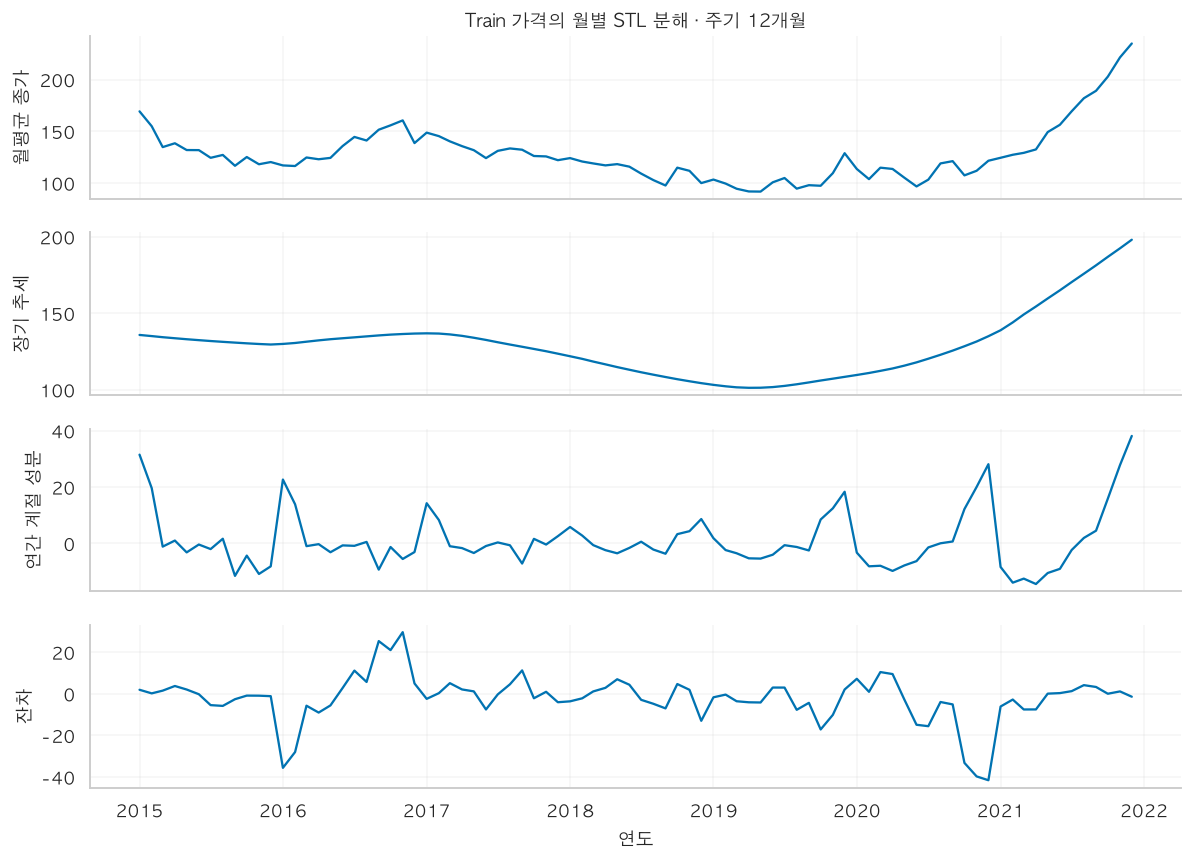

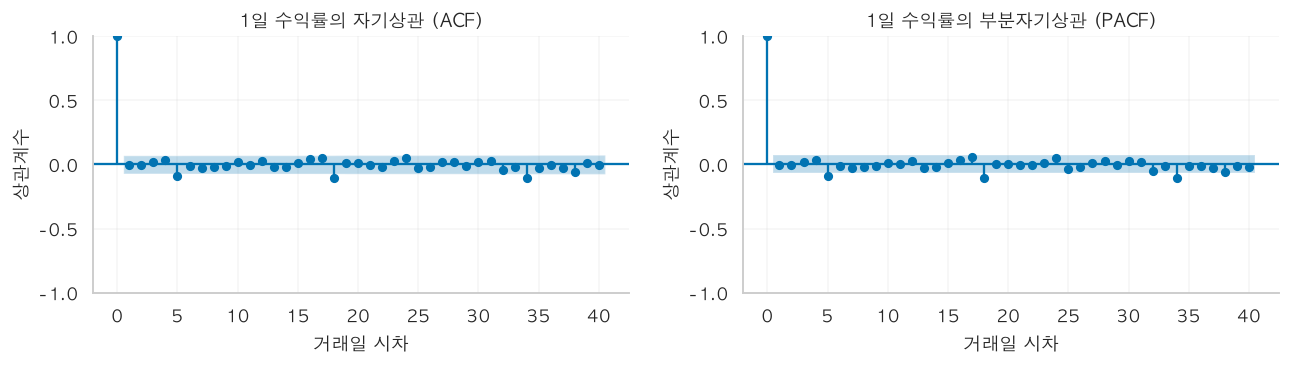

In [5]:
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings

train_price = prices.loc[TRAIN_START:TRAIN_END]
monthly = train_price.resample("MS").mean()
assert monthly.notna().all() and len(monthly) == 84
stl = STL(monthly, period=12, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, series, label in zip(axes, [monthly, stl.trend, stl.seasonal, stl.resid], ["월평균 종가", "장기 추세", "연간 계절 성분", "잔차"]):
    ax.plot(series.index, series)
    ax.set_ylabel(label)
axes[0].set_title("Train 가격의 월별 STL 분해 · 주기 12개월")
axes[-1].set_xlabel("연도")
fig.tight_layout()
plt.show()


def longest_valid(series):
    groups = series.notna().ne(series.notna().shift()).cumsum()
    candidates = [v for _,v in series.groupby(groups) if v.notna().all()]
    return max(candidates, key=len)

continuous_return = longest_valid(X.loc[TRAIN_START:TRAIN_END, "return_1"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(continuous_return, lags=40, ax=axes[0], title="1일 수익률의 자기상관 (ACF)")
plot_pacf(continuous_return, lags=40, ax=axes[1], method="ywm", title="1일 수익률의 부분자기상관 (PACF)")
for ax in axes:
    ax.set_xlabel("거래일 시차")
    ax.set_ylabel("상관계수")
fig.tight_layout()
plt.show()

In [6]:
stationarity = []
for name, series in [("종가", train_price)] + [(f"{h}일 미래 로그수익률", Y.loc[TRAIN_START:TRAIN_END, f"y_{h}"].where(Y.loc[TRAIN_START:TRAIN_END, f"target_date_{h}"].le(TRAIN_END))) for h in HORIZONS]:
    sample = longest_valid(series)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        adf_p = adfuller(sample, regression="c", autolag="AIC", result_object=False)[1]
        kpss_p = kpss(sample, regression="c", nlags="auto", result_object=False)[1]
    stationarity.append({"대상": name, "연속 표본": len(sample), "시작": str(sample.index[0].date()),
                         "끝": str(sample.index[-1].date()), "ADF p": adf_p, "KPSS p": kpss_p,
                         "왜도": stats.skew(sample), "초과첨도": stats.kurtosis(sample), "JB p": stats.jarque_bera(sample).pvalue})
stationarity = pd.DataFrame(stationarity)
stationarity_display = stationarity.copy()
for column in ("ADF p", "KPSS p", "JB p"):
    stationarity_display[column] = stationarity_display[column].map(lambda v: f"{v:.3g}")
display(Markdown(stationarity_display.to_markdown(index=False, disable_numparse=True)))
display(Markdown("ADF는 단위근, KPSS는 정상성이 귀무가설이다. KPSS의 0.01·0.10은 표의 하한·상한이다. "
                 "서로 다른 연속 구간을 쓸 수 있어 표본 기간도 함께 읽는다. 수익률의 두꺼운 꼬리와 중첩은 검정 해석을 제한한다."))

| 대상                 | 연속 표본   | 시작       | 끝         | ADF p   | KPSS p   | 왜도                 | 초과첨도            | JB p     |
|:---------------------|:------------|:-----------|:-----------|:--------|:---------|:---------------------|:--------------------|:---------|
| 종가                 | 774         | 2018-12-06 | 2021-12-31 | 0.986   | 0.01     | 1.5159982750642476   | 1.4225520398297116  | 2.82e-79 |
| 5일 미래 로그수익률  | 769         | 2018-12-06 | 2021-12-23 | 2.1e-05 | 0.1      | 0.5326245878981969   | 2.1095543739455556  | 1.38e-39 |
| 20일 미래 로그수익률 | 754         | 2018-12-06 | 2021-12-02 | 0.00109 | 0.0959   | -0.17170423733916282 | -0.2526889408284356 | 0.0575   |
| 60일 미래 로그수익률 | 714         | 2018-12-06 | 2021-10-06 | 0.00817 | 0.01     | -0.22053866265631797 | -0.7354355219656865 | 1.77e-05 |

ADF는 단위근, KPSS는 정상성이 귀무가설이다. KPSS의 0.01·0.10은 표의 하한·상한이다. 서로 다른 연속 구간을 쓸 수 있어 표본 기간도 함께 읽는다. 수익률의 두꺼운 꼬리와 중첩은 검정 해석을 제한한다.

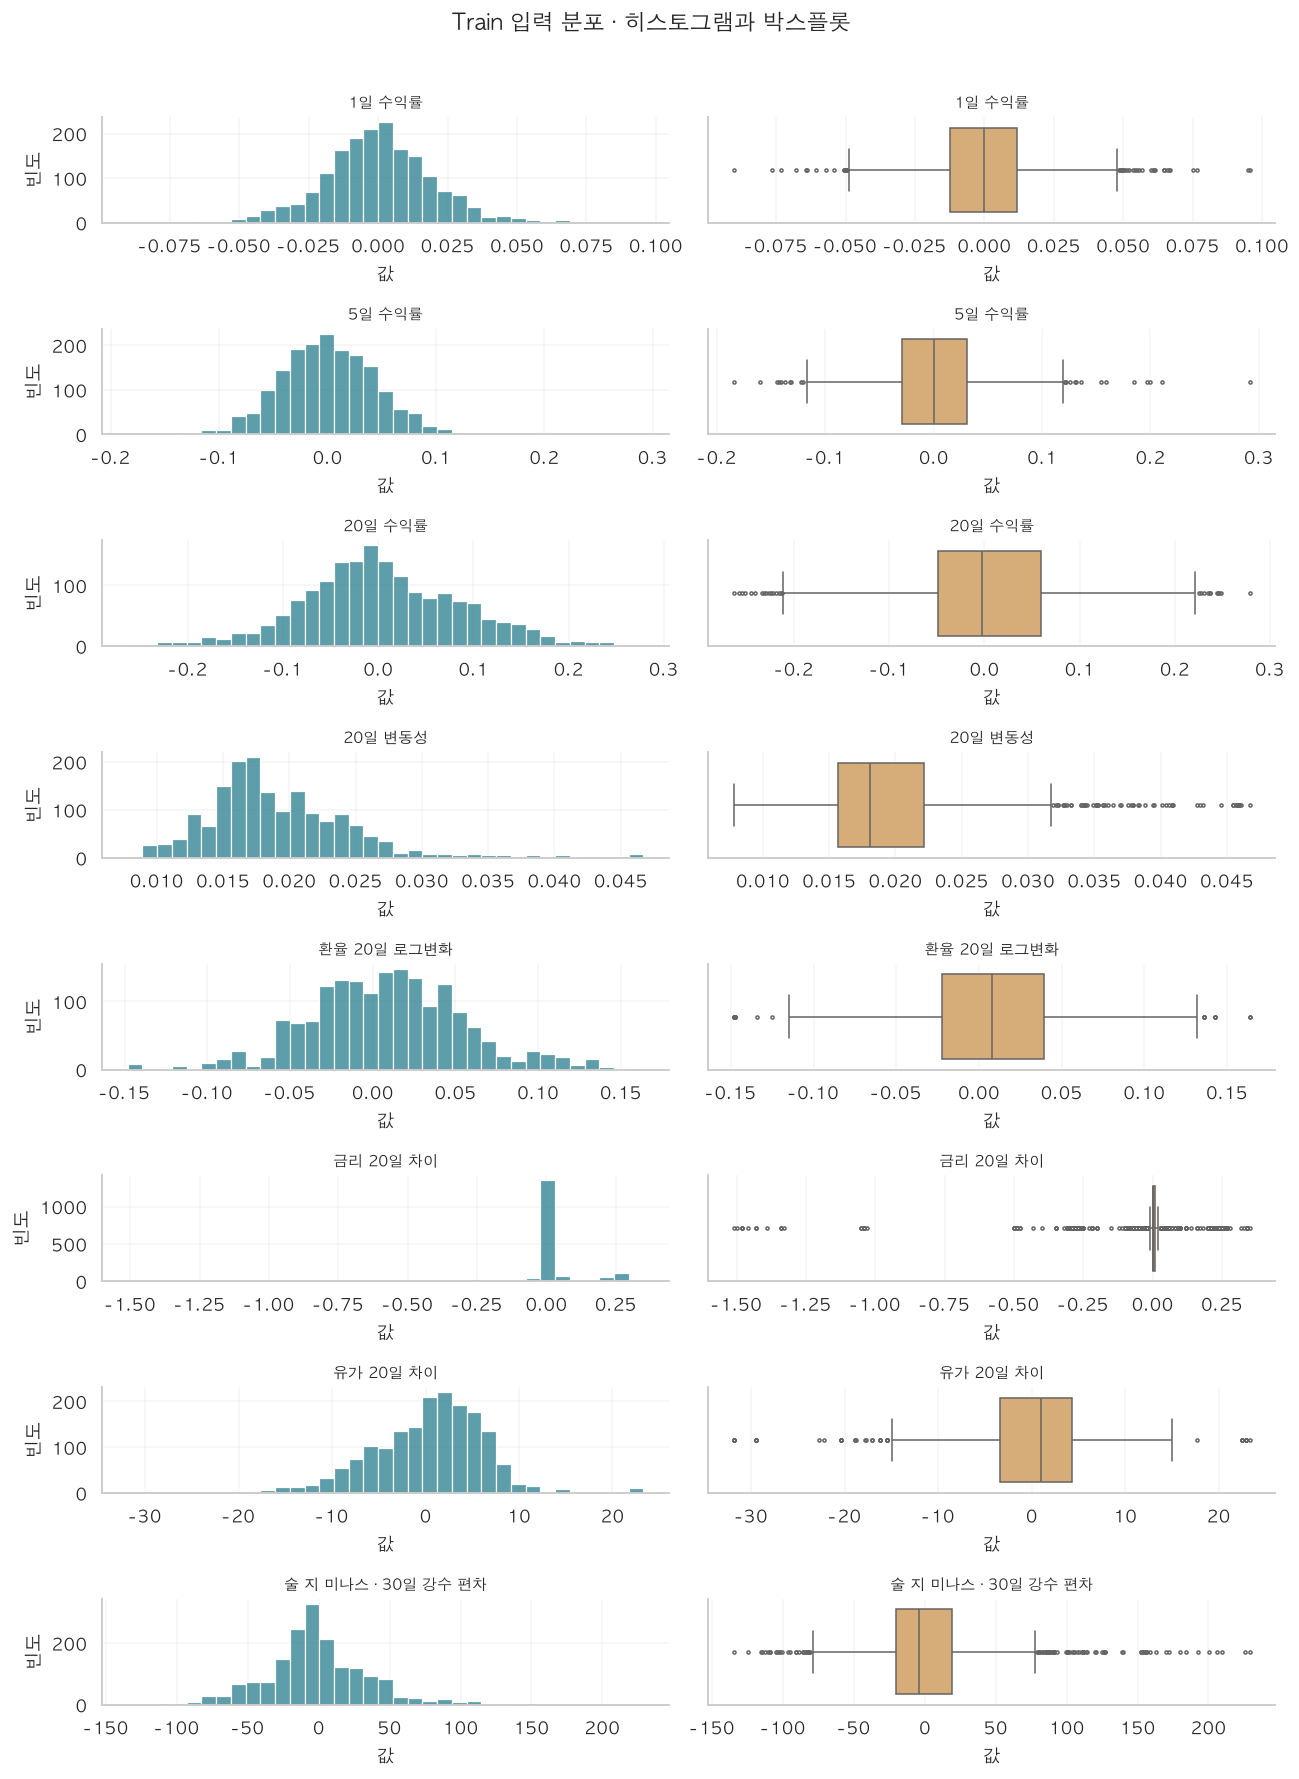

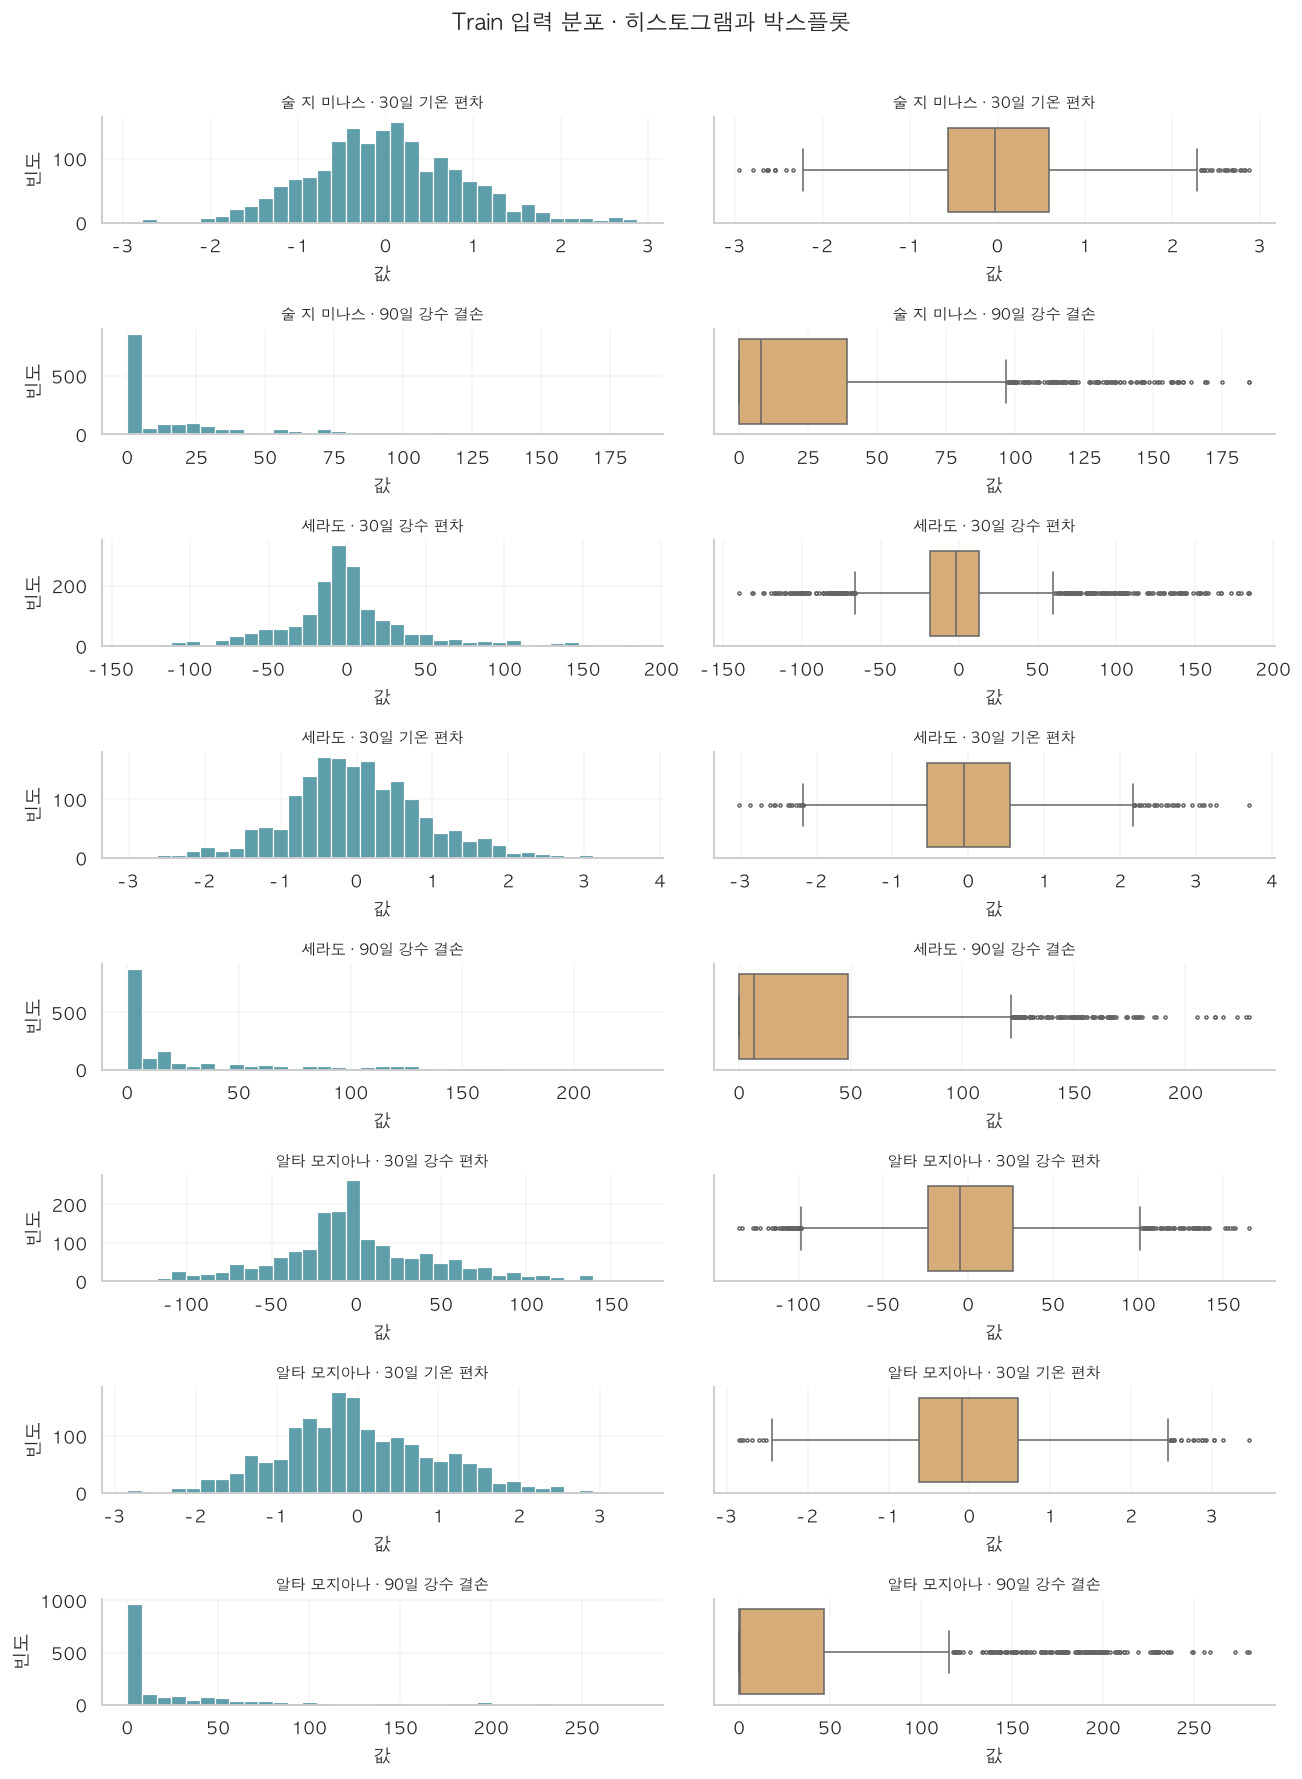

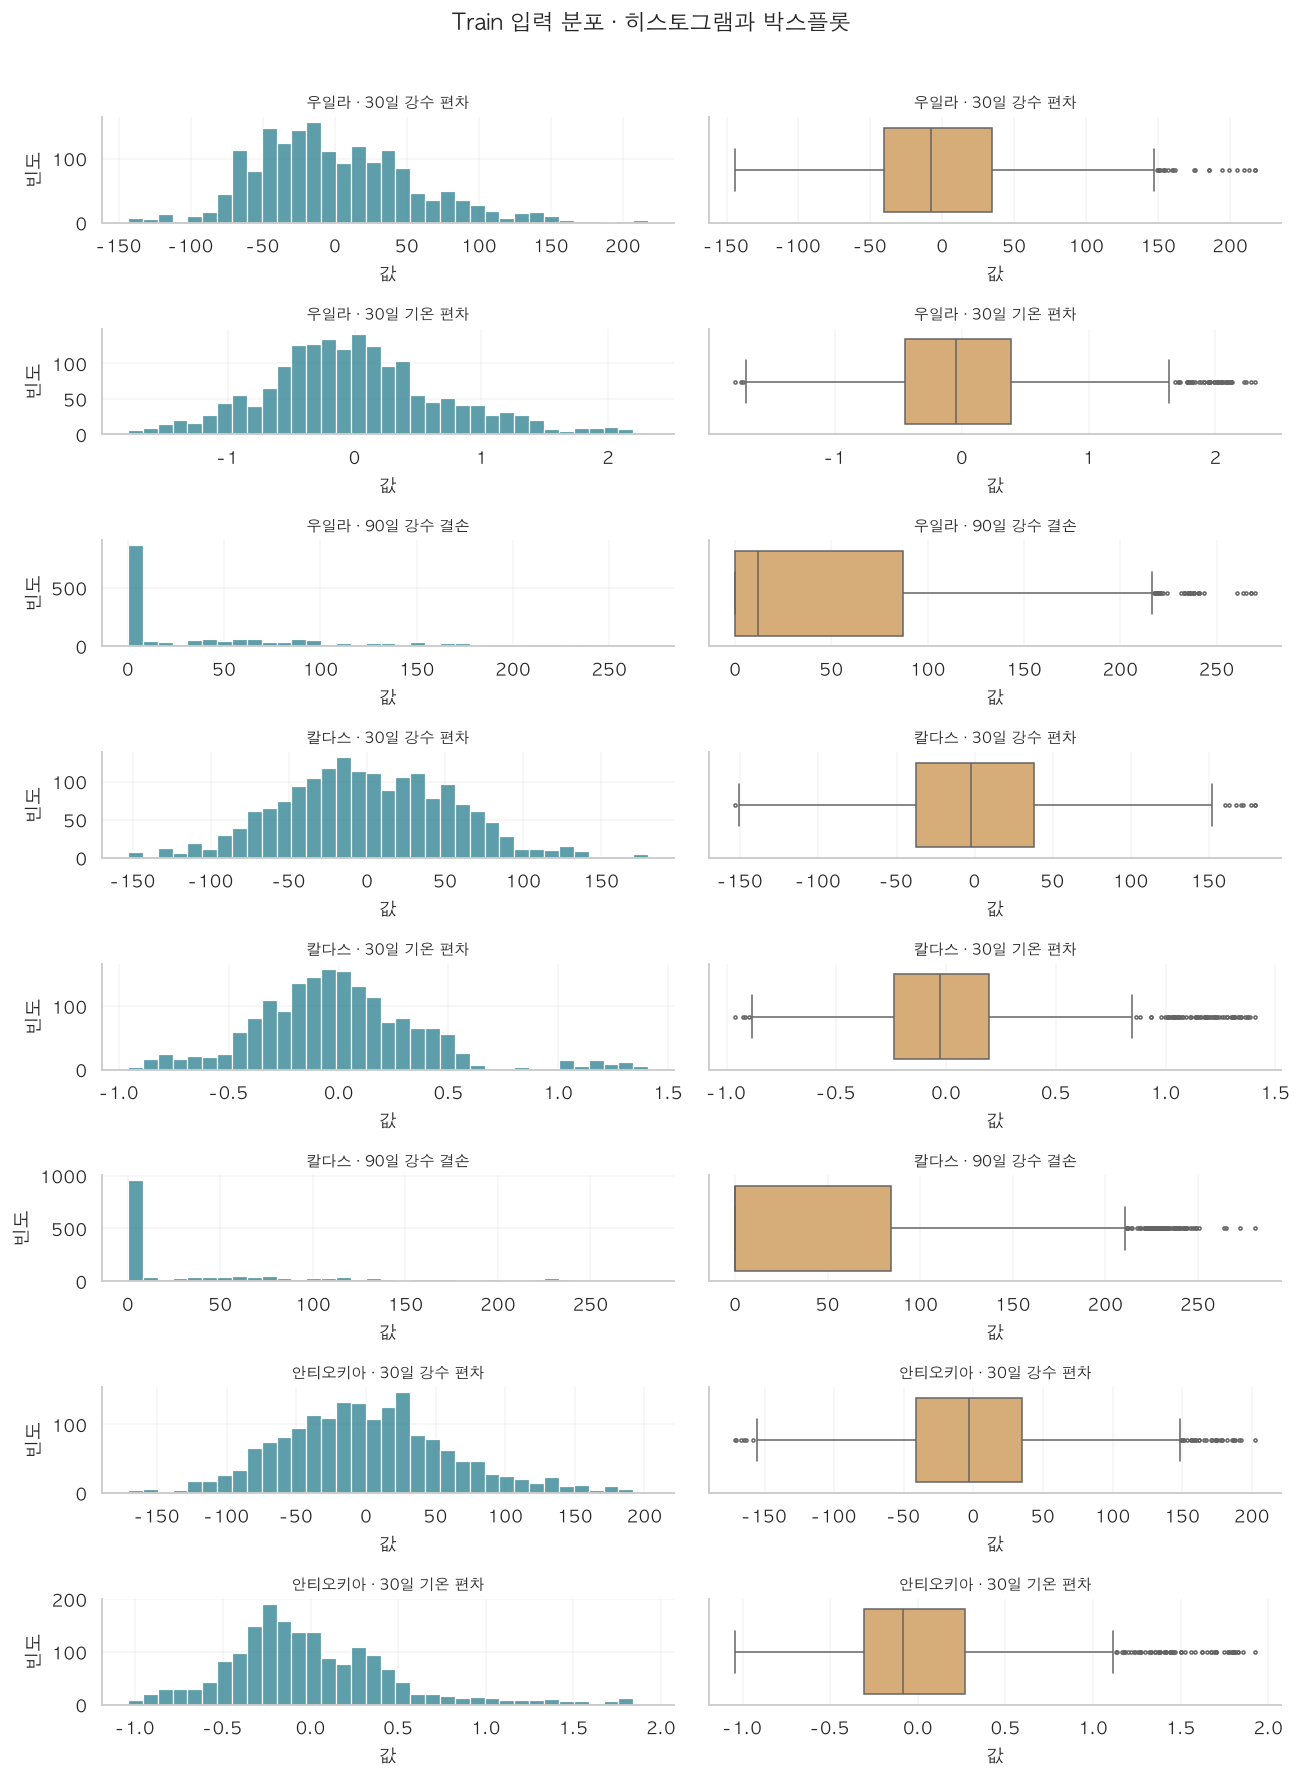

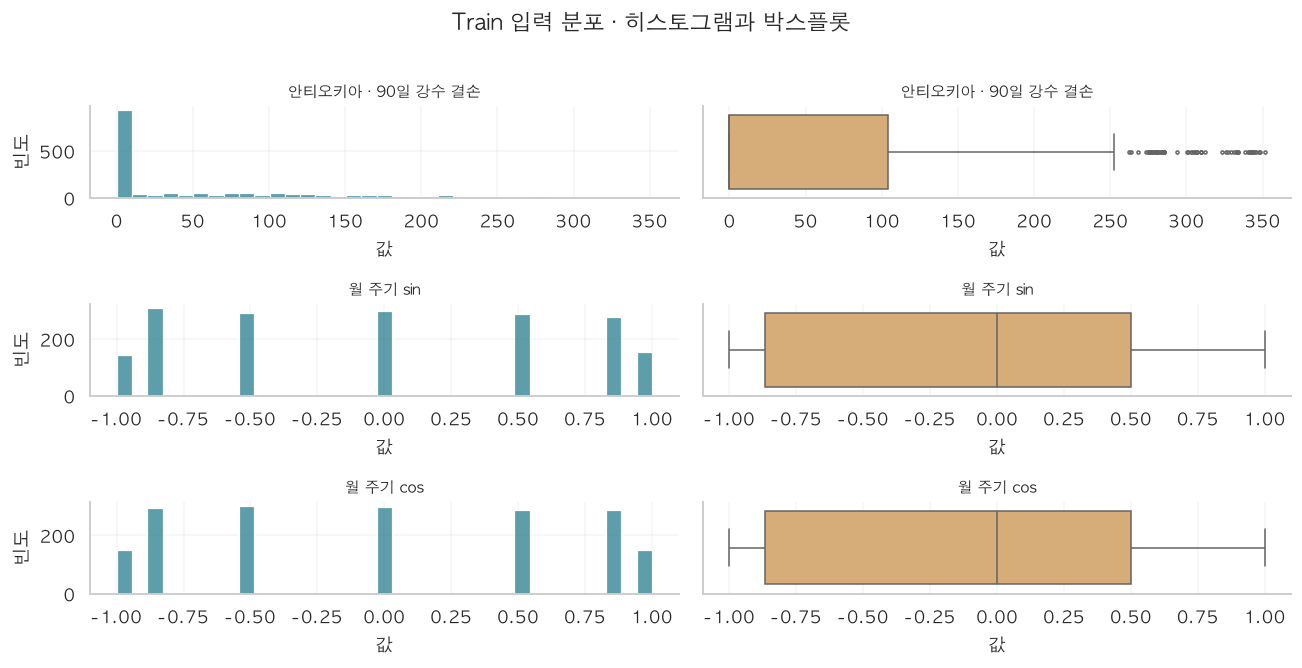

In [7]:
# 모델에 실제 들어갈 변수 전체를 본다. 값이 크다는 이유만으로 잘라내지 않는다.
train_X = X.loc[TRAIN_START:TRAIN_END, FEATURES]
for page in range(0, len(FEATURES), 8):
    columns = FEATURES[page:page+8]
    fig, axes = plt.subplots(len(columns), 2, figsize=(12, 2.0 * len(columns)))
    for (left, right), column in zip(axes, columns):
        values = train_X[column].dropna()
        sns.histplot(x=values, bins=35, ax=left, color="#287C8E")
        sns.boxplot(x=values, ax=right, color="#E6AF68", fliersize=2)
        left.set_title(LABELS[column], fontsize=10)
        right.set_title(LABELS[column], fontsize=10)
        left.set(xlabel="값", ylabel="빈도")
        right.set(xlabel="값", ylabel="")
    fig.suptitle("Train 입력 분포 · 히스토그램과 박스플롯", y=1.01)
    fig.tight_layout()
    plt.show()

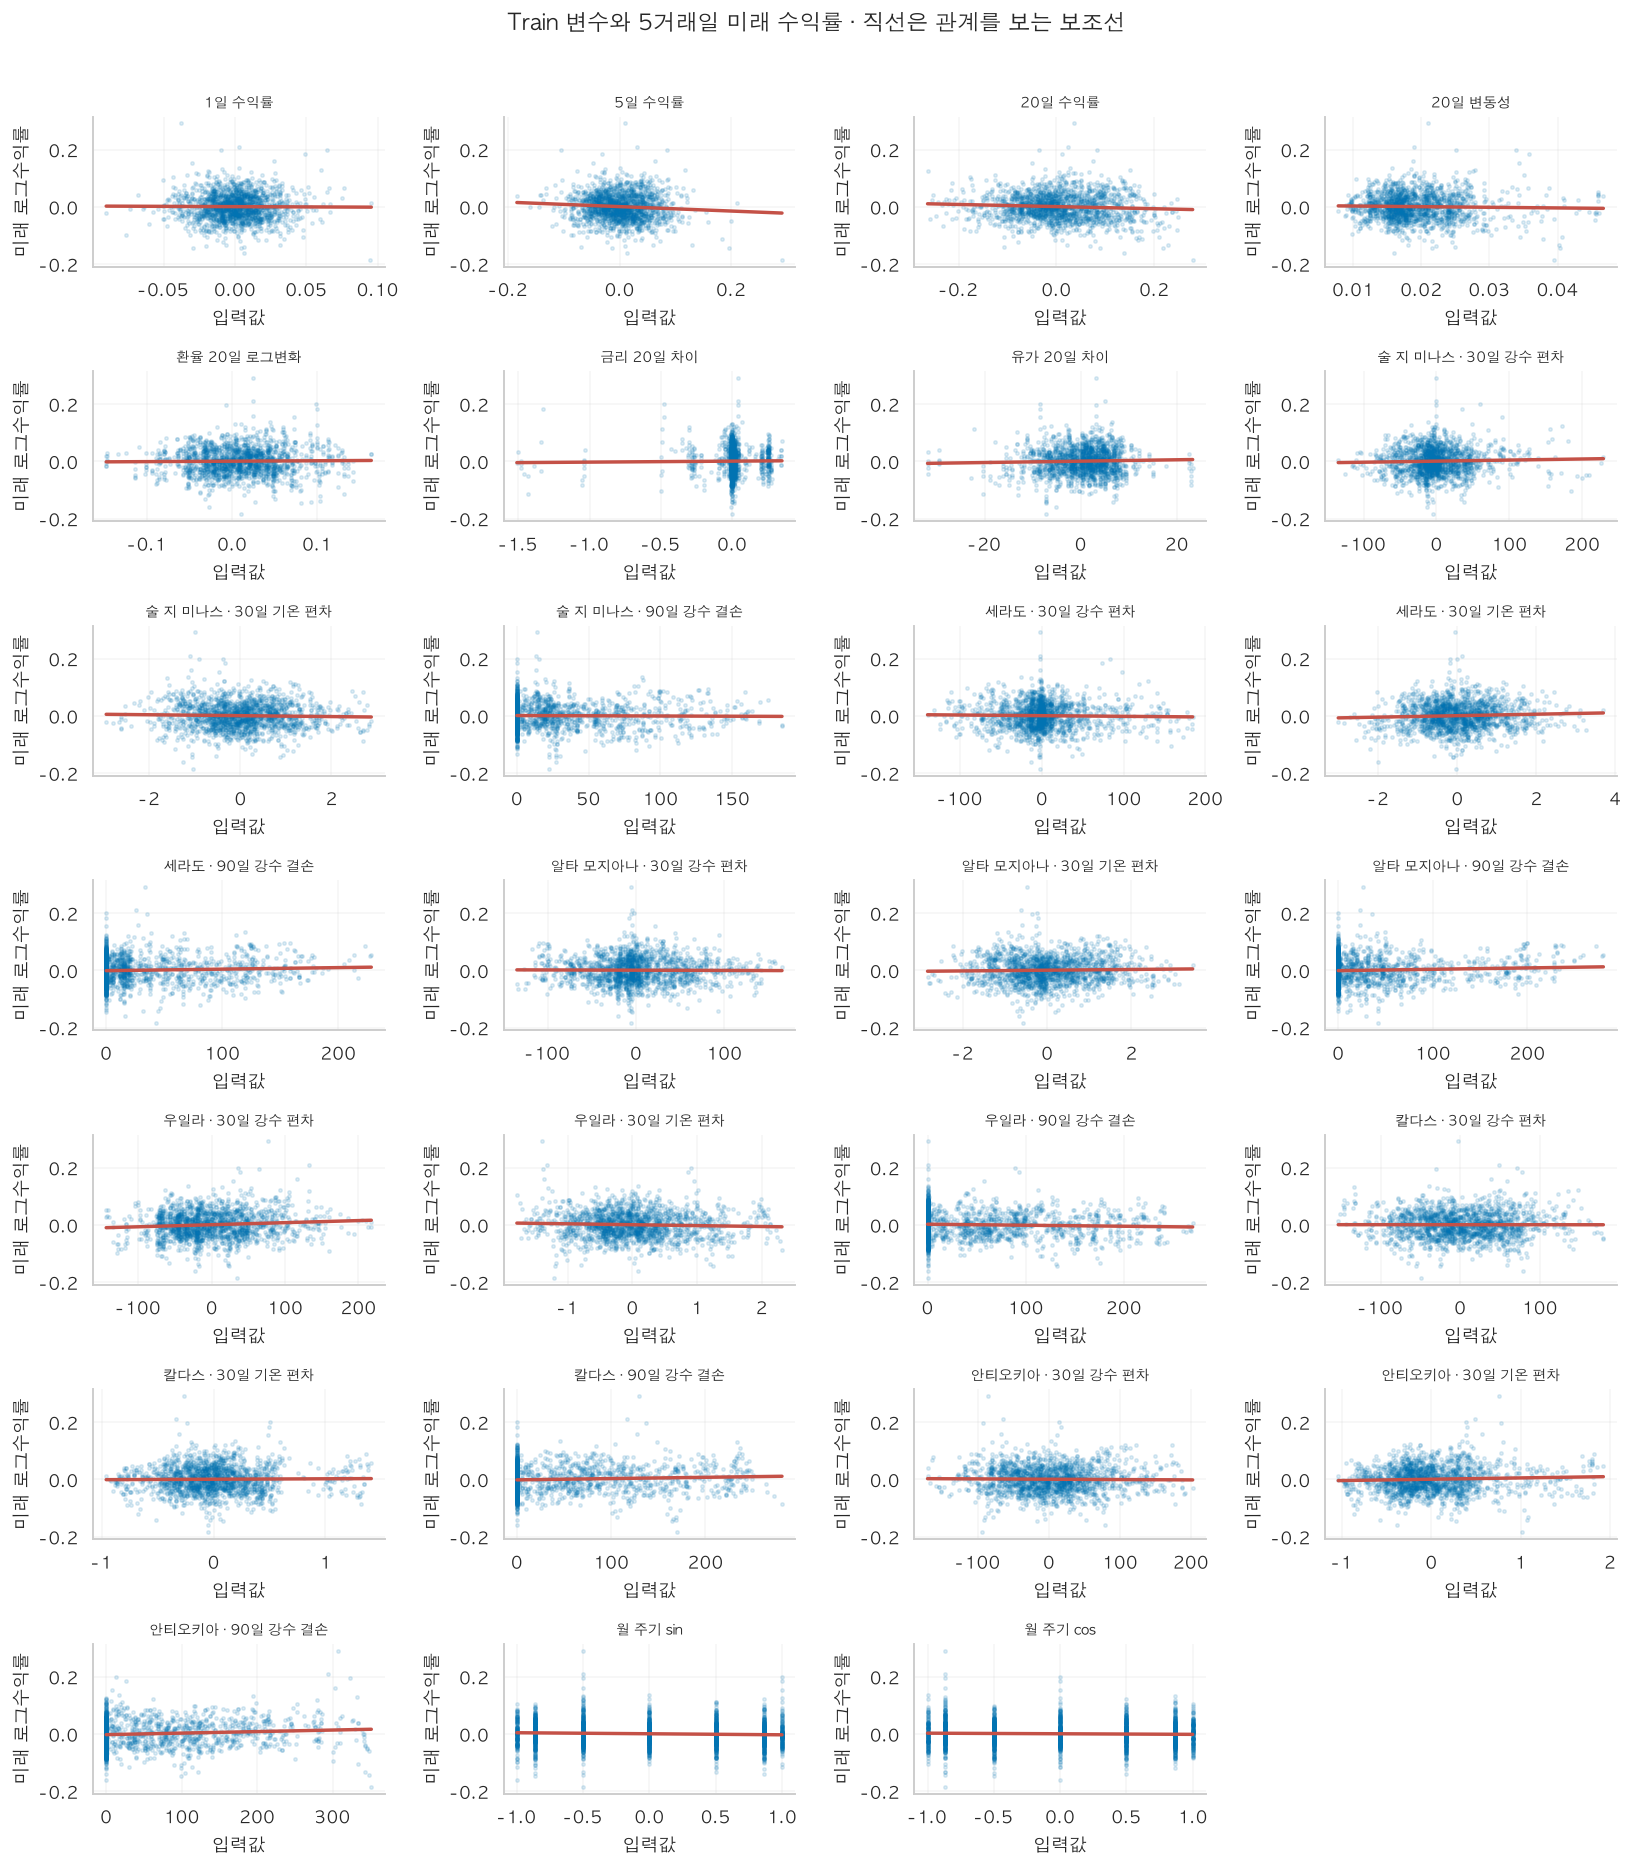

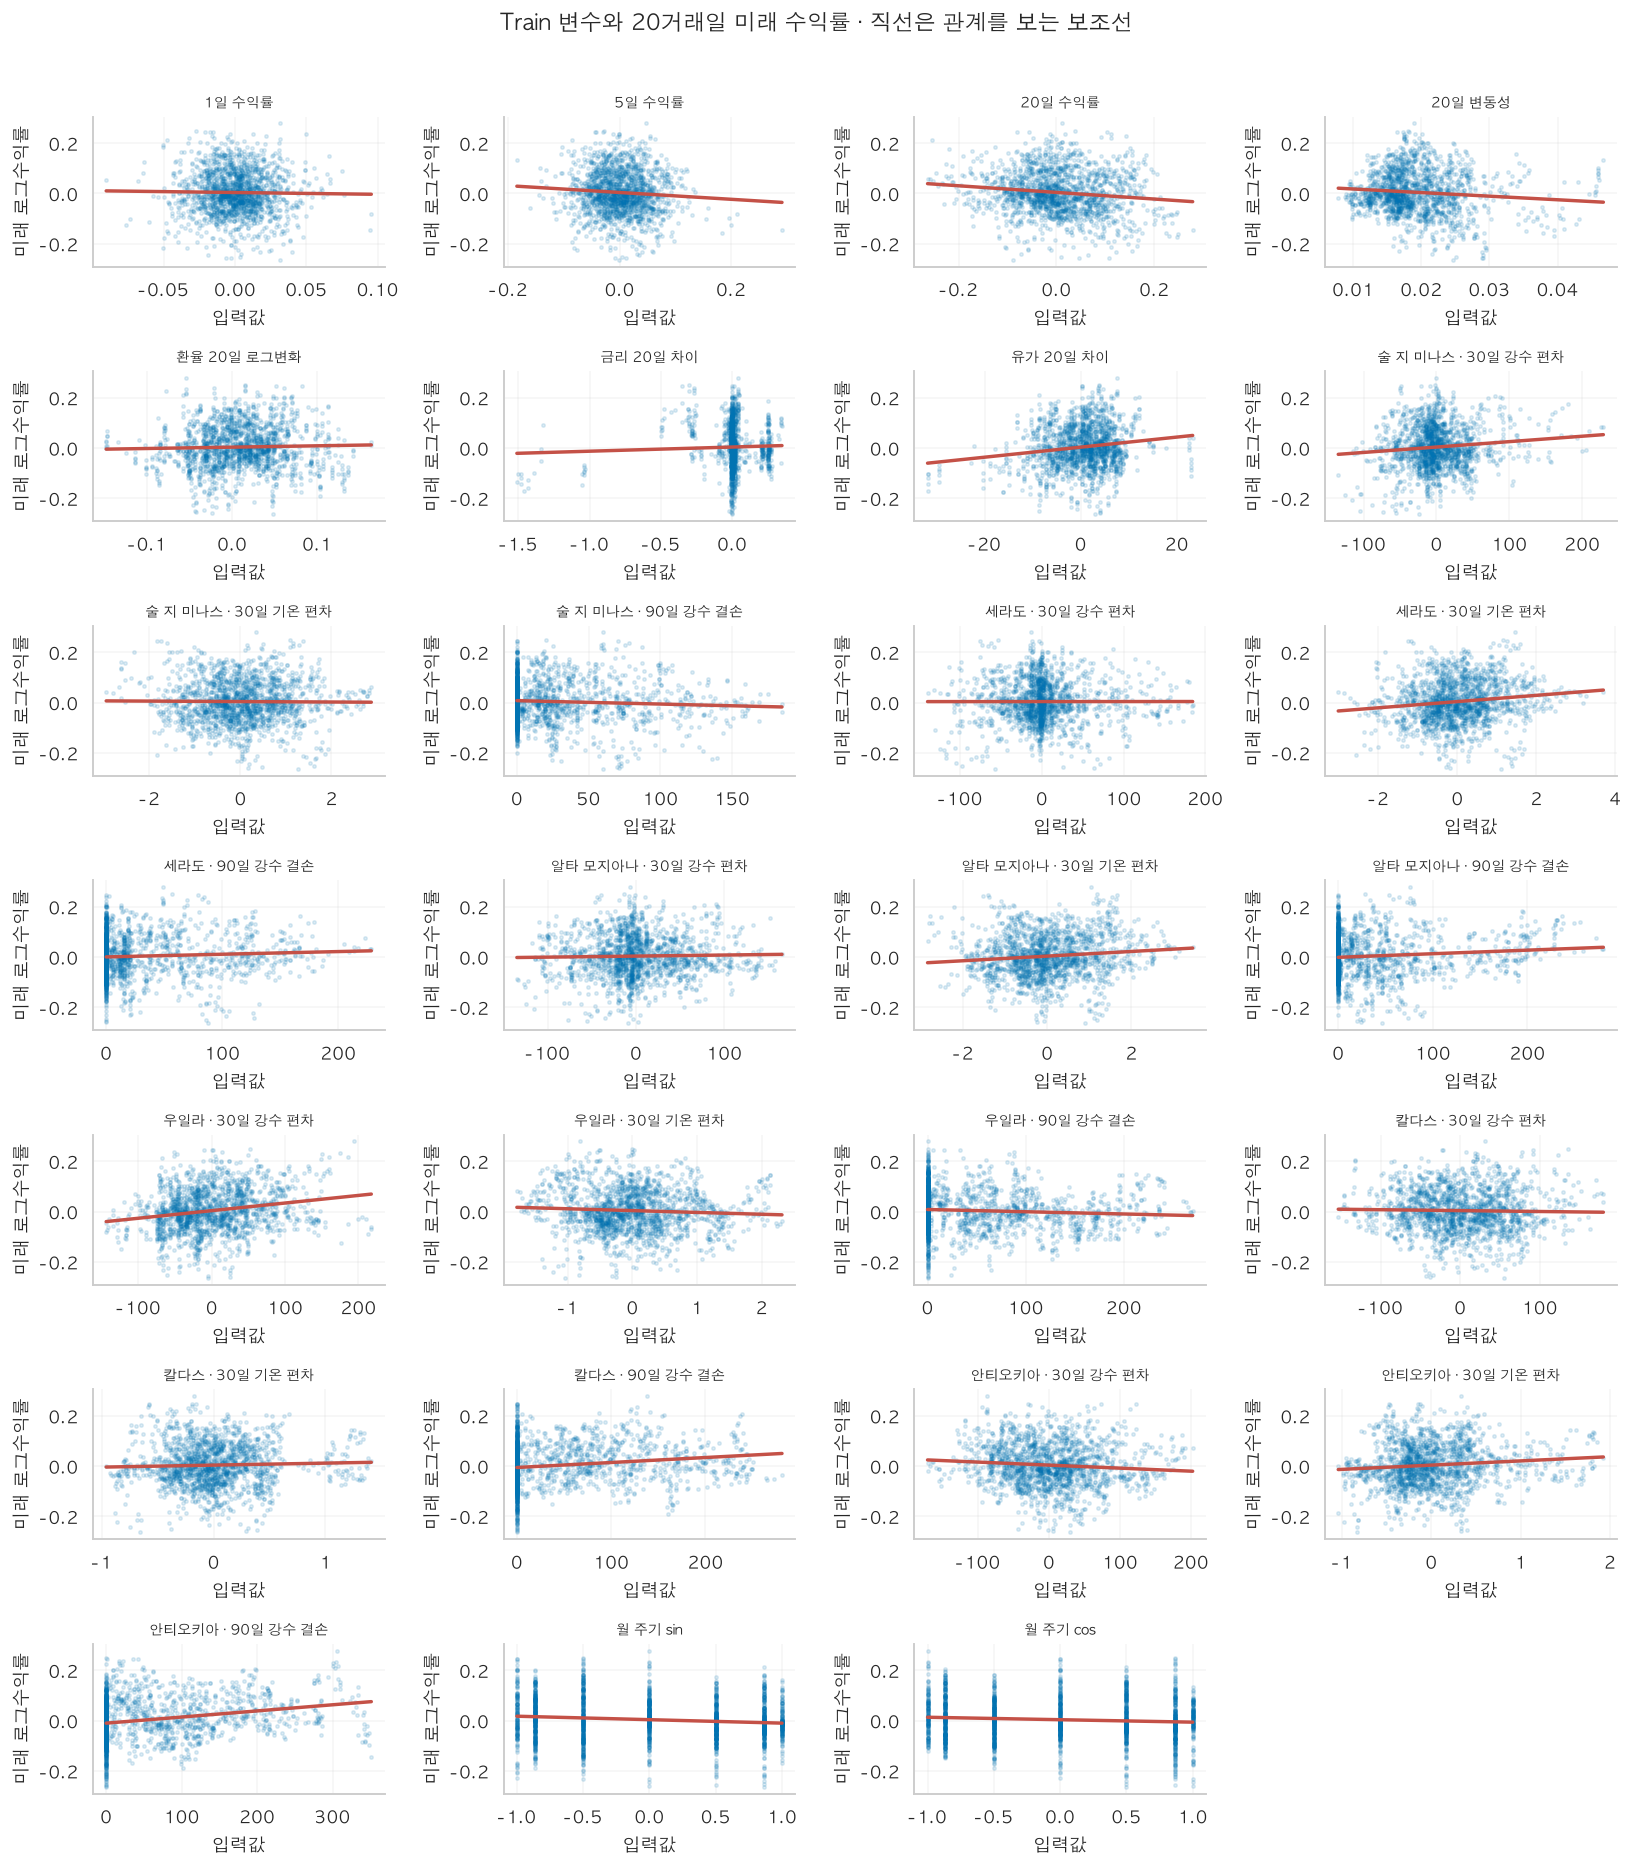

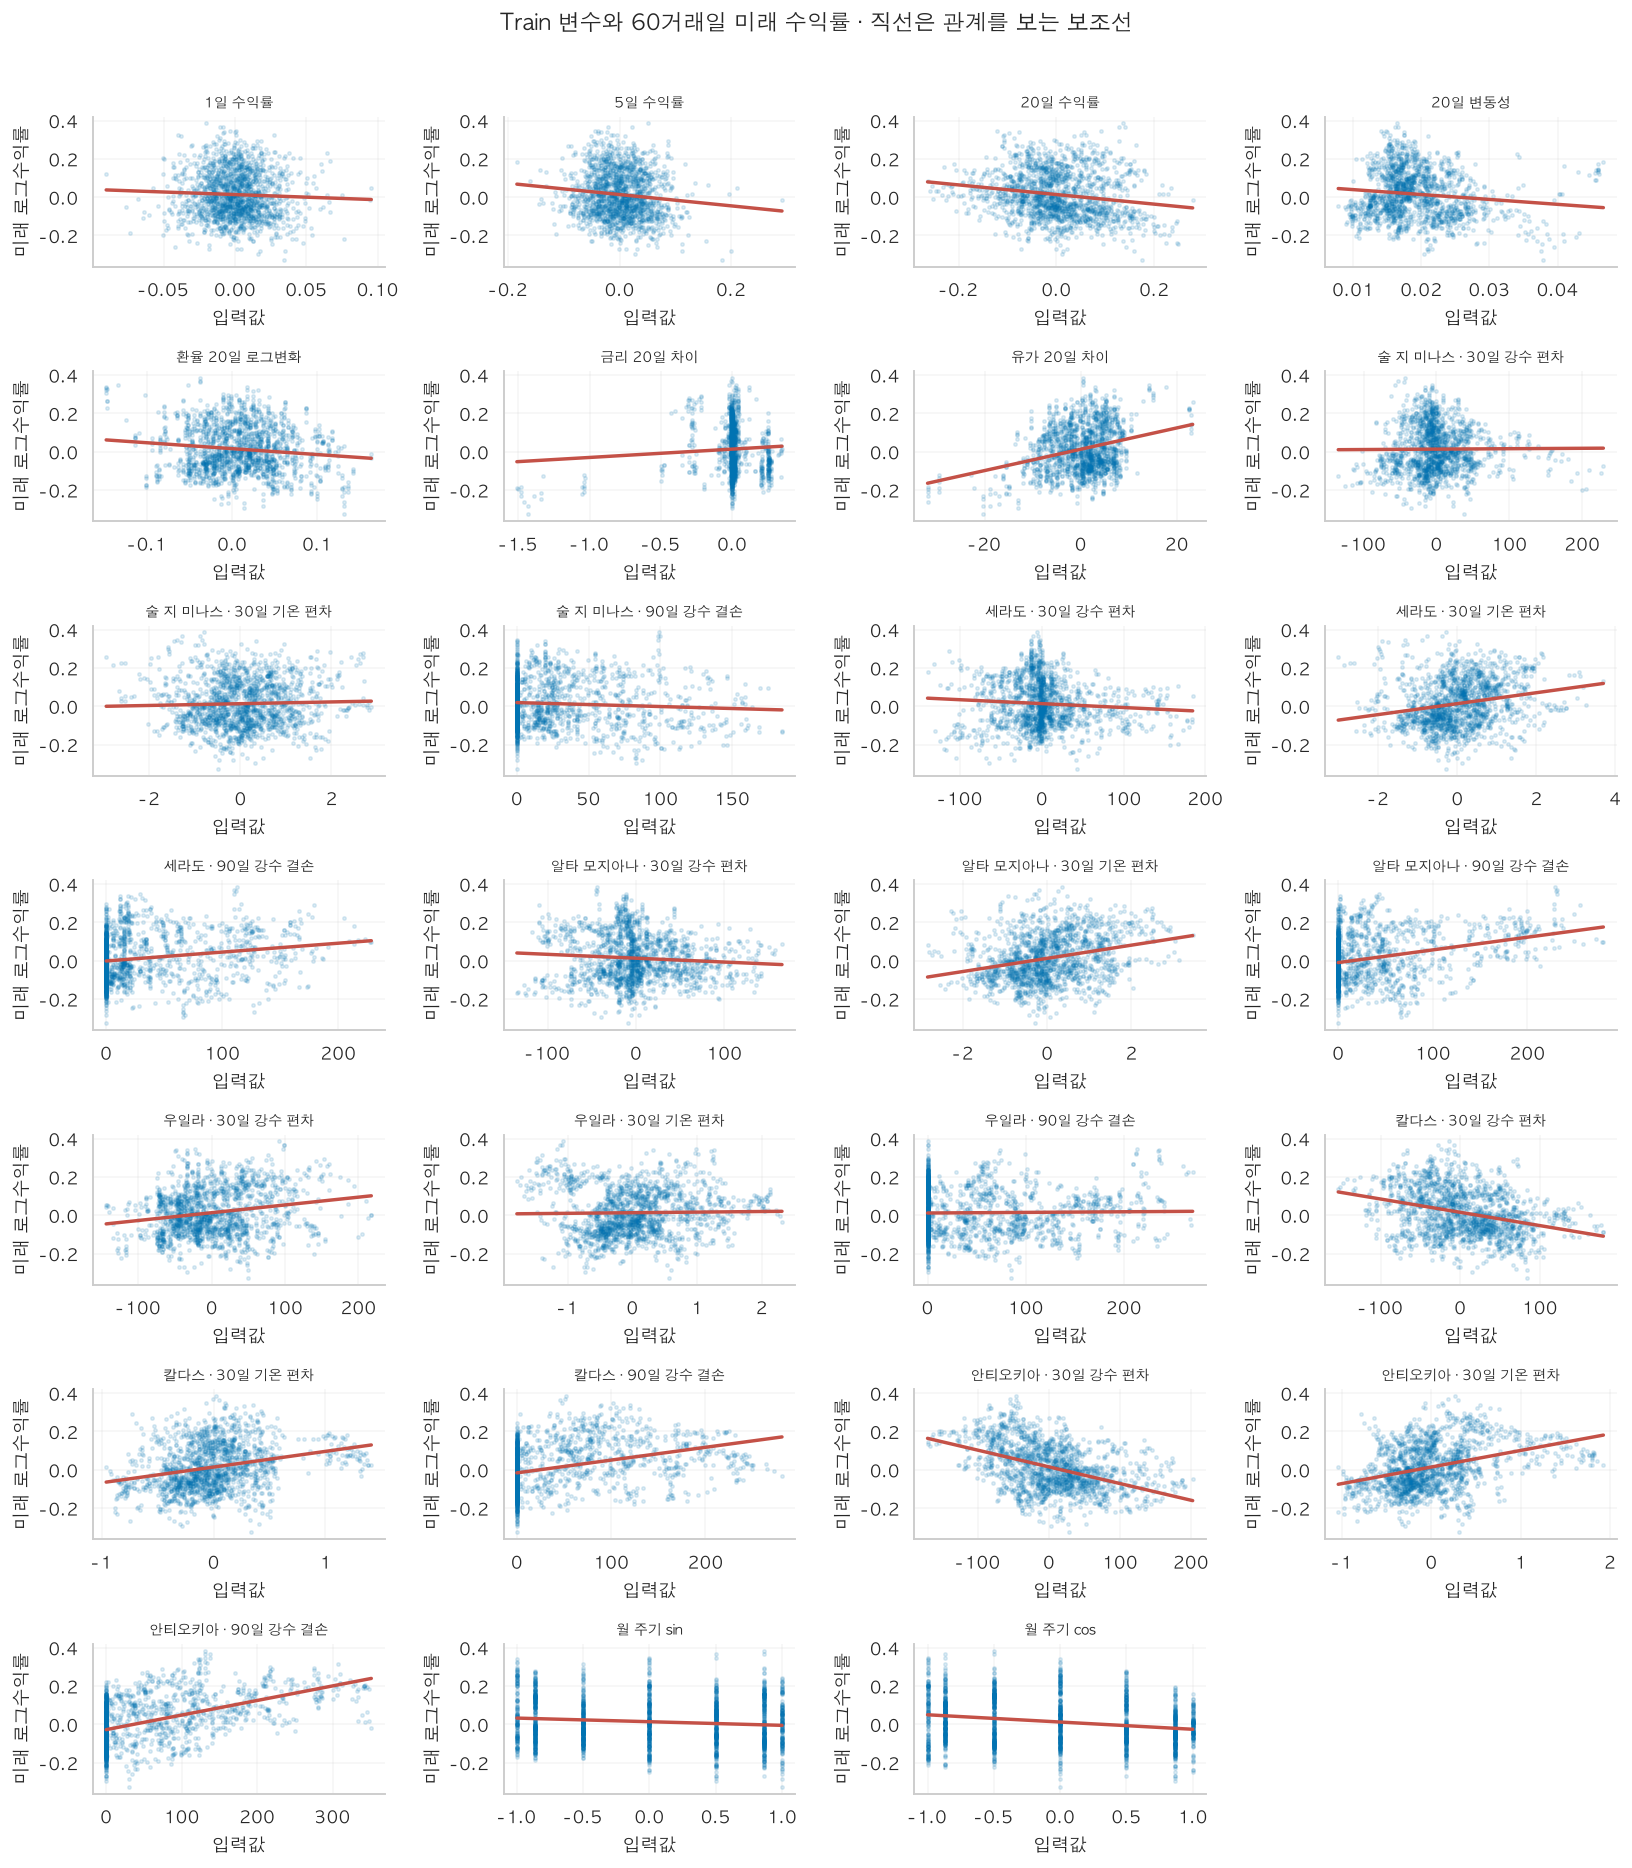

In [8]:
for h in HORIZONS:
    sample = X[FEATURES].join(Y[[f"y_{h}", f"target_date_{h}"]]).loc[TRAIN_START:TRAIN_END]
    sample = sample.loc[sample[f"target_date_{h}"].le(TRAIN_END)]
    fig, axes = plt.subplots(int(np.ceil(len(FEATURES)/4)), 4, figsize=(15, 2.4 * int(np.ceil(len(FEATURES)/4))))
    for ax, column in zip(axes.flat, FEATURES):
        sns.regplot(data=sample, x=column, y=f"y_{h}", ci=None,
                    scatter_kws={"s": 5, "alpha": .13}, line_kws={"color": "#C45147"}, ax=ax)
        ax.set(title=LABELS[column], xlabel="입력값", ylabel="미래 로그수익률")
        ax.title.set_fontsize(9)
    for ax in list(axes.flat)[len(FEATURES):]: ax.set_visible(False)
    fig.suptitle(f"Train 변수와 {h}거래일 미래 수익률 · 직선은 관계를 보는 보조선", y=1.01)
    fig.tight_layout()
    plt.show()

# 4. 시차를 탐색하고 피처 그룹을 비교하기

여기서 CCF는 거래일을 맞춘 `corr(X[t-k], log(P[t+h]/P[t]))`다.
입력 시차 `k=0~60`과 예측 지평 `h=5/20/60`을 구분한다. 공개 지연은 그 전에 이미 반영했다.
**큰 상관은 예측력이나 인과적 충격 도착 시간을 증명하지 않는다.** 중첩 수익률·계절성과 여러 시차 탐색의 영향을 받는다.
따라서 최고 시차를 자동으로 모델에 넣지 않고, 우선 정보원별 그룹을 비교한다.

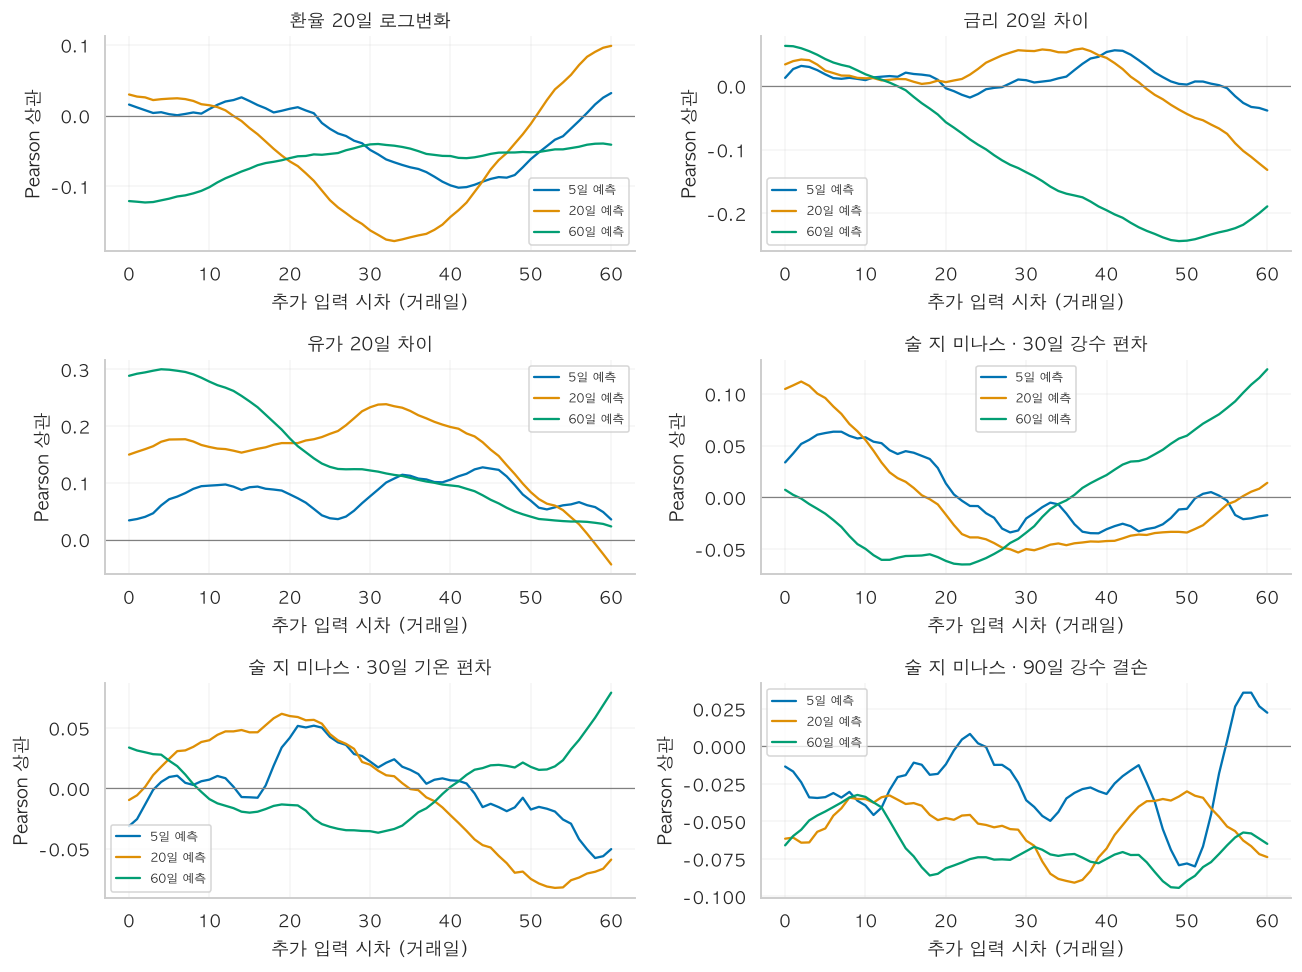

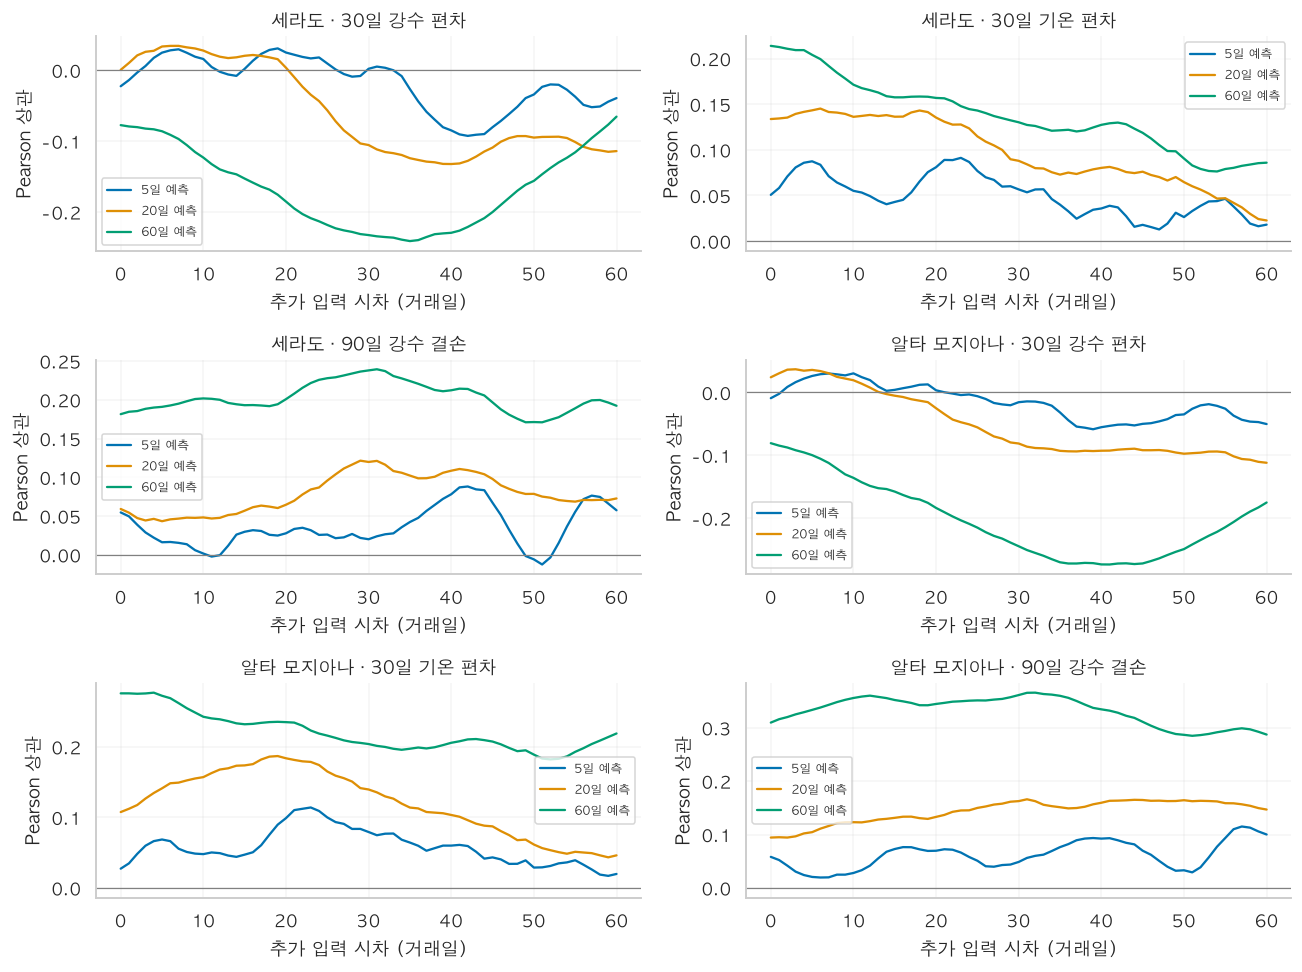

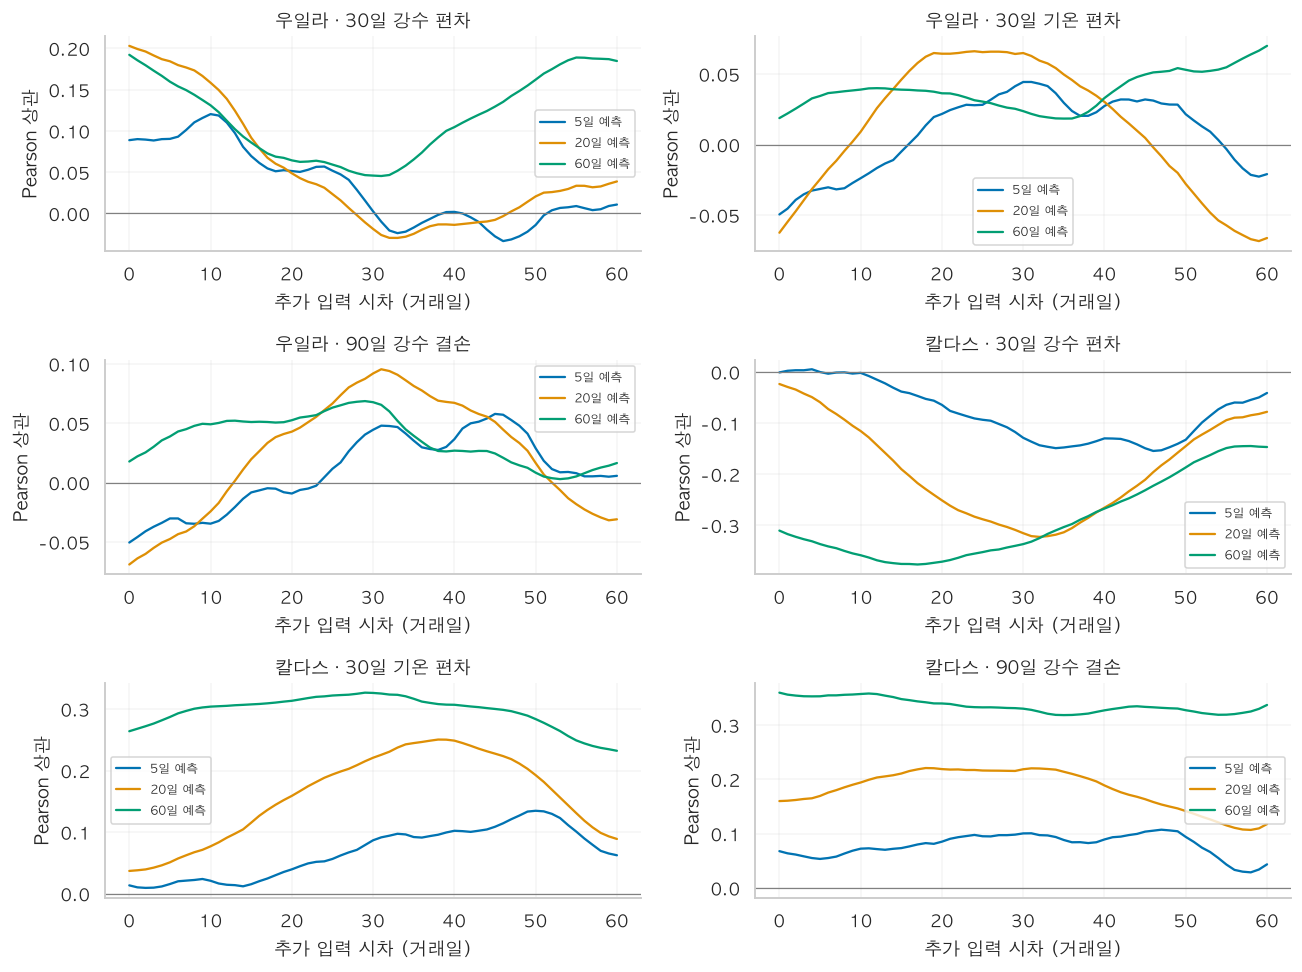

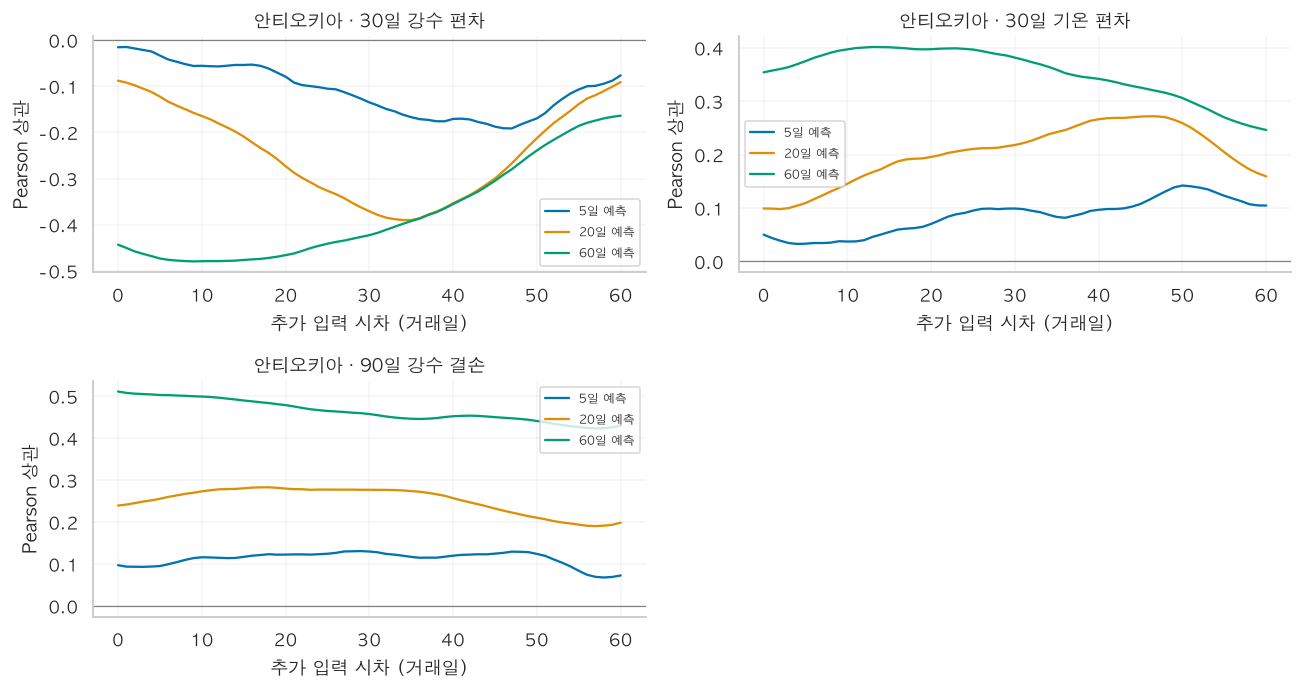

|   지평 | 변수                        |   탐색 시차 |   Pearson |   Spearman |   공통 행 |
|-------:|:----------------------------|------------:|----------:|-----------:|----------:|
|     60 | 안티오키아 · 90일 강수 결손 |           0 |   0.51104 |    0.51974 |      1698 |
|     60 | 안티오키아 · 30일 강수 편차 |           9 |  -0.47961 |   -0.47035 |      1698 |
|     60 | 안티오키아 · 30일 기온 편차 |          13 |   0.40156 |    0.42094 |      1698 |
|     20 | 안티오키아 · 30일 강수 편차 |          35 |  -0.38995 |   -0.37451 |      1738 |
|     20 | 칼다스 · 30일 강수 편차     |          32 |  -0.32258 |   -0.30123 |      1738 |
|     20 | 안티오키아 · 90일 강수 결손 |          18 |   0.28272 |    0.28252 |      1738 |
|      5 | 안티오키아 · 30일 강수 편차 |          47 |  -0.19154 |   -0.18223 |      1753 |
|      5 | 칼다스 · 30일 강수 편차     |          46 |  -0.15452 |   -0.15082 |      1753 |
|      5 | 안티오키아 · 30일 기온 편차 |          50 |   0.14214 |    0.13840 |      1753 |

In [9]:
external = MACRO + [c for c in WEATHER if c not in ("month_sin", "month_cos")]
ccf_records = []
for h in HORIZONS:
    lagged = pd.concat({k: X[external].shift(k) for k in range(61)}, axis=1)
    mask = (lagged.notna().all(axis=1) & Y[f"y_{h}"].notna()
            & Y[f"target_date_{h}"].le(TRAIN_END) & (X.index >= TRAIN_START) & (X.index <= TRAIN_END))
    target = Y.loc[mask, f"y_{h}"]
    for column in external:
        for k in range(61):
            x = lagged.loc[mask, (k, column)]
            ccf_records.append({"h": h, "feature": column, "lag": k, "r": x.corr(target),
                                "rho": x.corr(target, method="spearman"), "n": len(target)})
ccf = pd.DataFrame(ccf_records)
for page in range(0, len(external), 6):
    fig, axes = plt.subplots(3, 2, figsize=(12, 9))
    for ax, column in zip(axes.flat, external[page:page+6]):
        for h in HORIZONS:
            part = ccf.loc[(ccf.feature == column) & (ccf.h == h)]
            ax.plot(part.lag, part.r, label=f"{h}일 예측")
        ax.axhline(0, color="gray", lw=.8)
        ax.set(title=LABELS[column], xlabel="추가 입력 시차 (거래일)", ylabel="Pearson 상관")
        ax.legend(fontsize=8)
    for ax in list(axes.flat)[len(external[page:page+6]):]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
top_ccf = ccf.loc[ccf.groupby(["h", "feature"]).r.apply(lambda v: v.abs().idxmax())].copy()
top_ccf["변수"] = top_ccf.feature.map(LABELS)
show_table(top_ccf.sort_values("r", key=lambda s: s.abs(), ascending=False).groupby("h").head(3)
           .rename(columns={"h":"지평", "lag":"탐색 시차", "r":"Pearson", "rho":"Spearman", "n":"공통 행"})
           [["지평", "변수", "탐색 시차", "Pearson", "Spearman", "공통 행"]])

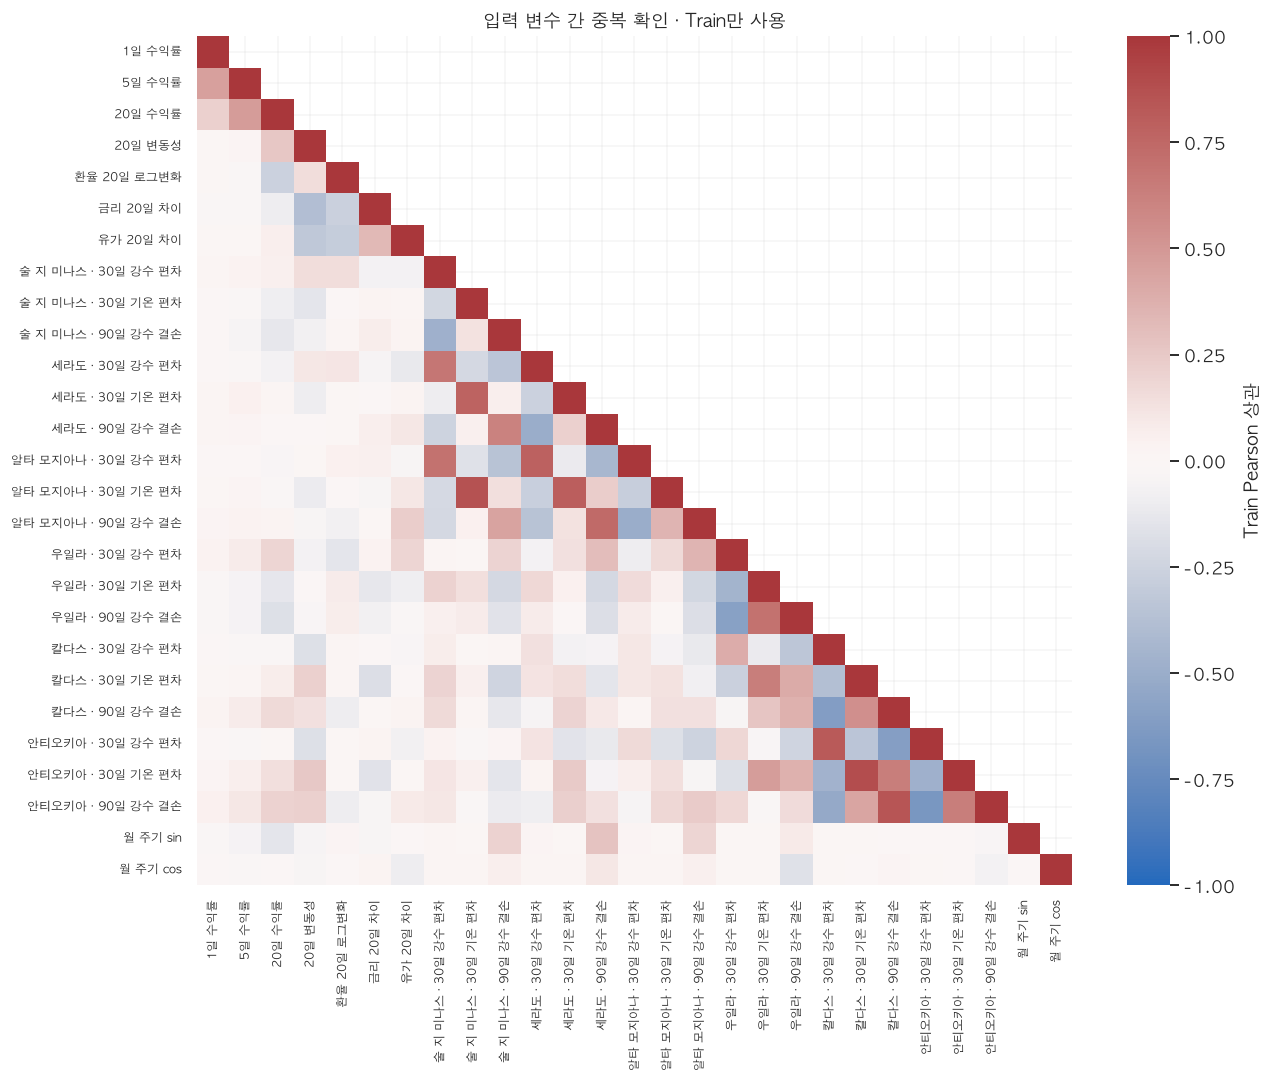

월별 편차 변환 후 |r| ≥ 0.90인 기상 쌍이 없어 축소 후보는 생략합니다.


In [10]:
fig, ax = plt.subplots(figsize=(12, 10))
correlation = train_X.rename(columns=LABELS).corr()
sns.heatmap(correlation, vmin=-1, vmax=1, center=0, cmap="vlag", ax=ax,
            mask=np.triu(np.ones_like(correlation, dtype=bool), k=1),
            cbar_kws={"label": "Train Pearson 상관"})
ax.set_title("입력 변수 간 중복 확인 · Train만 사용")
ax.tick_params(labelsize=8)
fig.tight_layout()
plt.show()


def reduced_weather(features, target, end):
    candidate = [c for c in WEATHER if c not in ("month_sin", "month_cos")]
    sample = features[candidate].join(target.rename("target")).loc[TRAIN_START:end].dropna()
    scores = sample[candidate].corrwith(sample.target).abs().fillna(0)
    corr = sample[candidate].corr().abs()
    keep, removed = [], []
    # 상관이 높은 쌍에서 타깃 관계가 약한 쪽을 뺀 후보. 성능은 Validation에서 다시 확인한다.
    for column in sorted(candidate, key=lambda c: (-scores[c], c)):
        partner = next((kept for kept in keep if corr.loc[column, kept] >= .90), None)
        if partner is None:
            keep.append(column)
        else:
            removed.append({"제외 후보": LABELS[column], "남긴 변수": LABELS[partner],
                            "변수 간 |r|": corr.loc[column, partner], "제외 후보 |타깃 r|": scores[column]})
    return [c for c in WEATHER if c in keep or c in ("month_sin", "month_cos")], removed

GROUPS, reductions = {}, []
for h in HORIZONS:
    target = Y[f"y_{h}"].where(Y[f"target_date_{h}"].le(TRAIN_END))
    reduced, removed = reduced_weather(X, target, TRAIN_END)
    GROUPS[h] = {"가격": PRICE, "가격+거시": PRICE+MACRO, "가격+기후": PRICE+WEATHER,
                 "가격+거시+기후": FEATURES}
    if removed:
        GROUPS[h]["가격+거시+축소기후"] = PRICE+MACRO+reduced
    reductions.extend({"지평": h, **row} for row in removed)
if reductions:
    show_table(pd.DataFrame(reductions))
else:
    print("월별 편차 변환 후 |r| ≥ 0.90인 기상 쌍이 없어 축소 후보는 생략합니다.")

그룹 비교는 CatBoost **150개 트리·깊이 4·학습률 0.03·L2 규제 5·seed 42**로 통일한다.
가격 / 가격+거시 / 가격+기후 / 전체를 비교하고, 제거할 중복 쌍이 있을 때만 축소 후보를 추가한다.
전체에서 거시를 빼면 가격+기후, 기후를 빼면 가격+거시이므로 같은 실험을 중복 실행하지 않는다.

상수 피처와 중복 후보는 Train에서만 정한다. VIF나 높은 변수 상관만으로 트리 모델의 입력을 확정하지 않는다.
같은 지평 안에서는 모든 그룹에 **동일한 학습·평가 날짜와 30거래일 입력 유효 조건**을 적용한다.
최저 Validation RMSE로 그룹을 선택하며, 동률이면 피처가 적은 쪽을 고른다.

In [11]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


def metrics(actual, predicted):
    actual, predicted = np.asarray(actual), np.asarray(predicted)
    assert actual.shape == predicted.shape and np.isfinite(predicted).all()
    rmse = root_mean_squared_error(actual, predicted)
    naive = root_mean_squared_error(actual, np.zeros_like(actual))
    return {"RMSE": rmse, "MAE": mean_absolute_error(actual, predicted),
            "방향 정확도 (%)": 100*np.mean(np.sign(actual) == np.sign(predicted)),
            "Naive 대비 개선 (%)": 100*(1-rmse/naive)}


def catboost(trees=150):
    return CatBoostRegressor(iterations=trees, depth=4, learning_rate=.03, l2_leaf_reg=5,
                             loss_function="RMSE", random_seed=SEED, verbose=False,
                             thread_count=1, allow_writing_files=False)

ablation_rows, selected_group = [], {}
for h in HORIZONS:
    tr, va = SPLITS[h]["Train"], SPLITS[h]["Validation"]
    for name, columns in GROUPS[h].items():
        model = catboost().fit(X.iloc[tr][columns], Y.iloc[tr][f"y_{h}"])
        pred = model.predict(X.iloc[va][columns])
        ablation_rows.append({"지평": h, "구간": "Validation", "그룹": name, "피처 수": len(columns),
                              **metrics(Y.iloc[va][f"y_{h}"], pred)})
    result = pd.DataFrame(ablation_rows).query("지평 == @h")
    selected_group[h] = result.sort_values(["RMSE", "피처 수", "그룹"]).iloc[0]["그룹"]
ablation_validation = pd.DataFrame(ablation_rows)
show_table(ablation_validation)
print("Validation에서 고정한 그룹:", selected_group)

|   지평 | 구간   | 그룹           |   피처 수 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------|:---------------|----------:|--------:|--------:|------------------:|----------------------:|
|      5 | 검증   | 가격           |         4 | 0.04773 | 0.03839 |          47.58065 |              -1.40356 |
|      5 | 검증   | 가격+거시      |         7 | 0.04770 | 0.03805 |          49.19355 |              -1.34822 |
|      5 | 검증   | 가격+기후      |        24 | 0.04773 | 0.03808 |          48.58871 |              -1.40121 |
|      5 | 검증   | 가격+거시+기후 |        27 | 0.04791 | 0.03836 |          45.36290 |              -1.79188 |
|     20 | 검증   | 가격           |         4 | 0.10294 | 0.08209 |          36.17464 |             -13.09771 |
|     20 | 검증   | 가격+거시      |         7 | 0.09901 | 0.07900 |          38.04574 |              -8.78191 |
|     20 | 검증   | 가격+기후      |        24 | 0.09288 | 0.07370 |          55.09356 |              -2.04924 |
|     20 | 검증   | 가격+거시+기후 |        27 | 0.09146 | 0.07138 |          55.09356 |              -0.48968 |
|     60 | 검증   | 가격           |         4 | 0.17708 | 0.14208 |          35.37415 |             -10.82079 |
|     60 | 검증   | 가격+거시      |         7 | 0.16968 | 0.13826 |          45.80499 |              -6.19086 |
|     60 | 검증   | 가격+기후      |        24 | 0.15859 | 0.13379 |          51.02041 |               0.75231 |
|     60 | 검증   | 가격+거시+기후 |        27 | 0.15255 | 0.12843 |          53.96825 |               4.53044 |

Validation에서 고정한 그룹: {5: '가격+거시', 20: '가격+거시+기후', 60: '가격+거시+기후'}


# 5. 가격 기준 모델과 머신러닝 비교

두 질문을 나눈다. **① 같은 CatBoost에 어떤 그룹이 도움이 되는가? ② 선택한 그룹에서 어떤 모델이 나은가?**
그룹 선택은 머신러닝 입력에만 적용한다. 지수평활·ARIMA는 항상 가격 단변량이다.
모델별로 그룹을 다시 탐색하지 않아 비교 범위를 작게 유지한다. 이 선택이 다른 모델에 최적인 것은 아니다.

| 모델 | Validation에서 비교할 설정 |
|---|---|
| 가격 유지 | 미래 로그수익률 = 0 |
| PyCaret · 지수평활 / ARIMA | 비계절 단순 지수평활 / ARIMA(1,1,0), 설정 고정 |
| Ridge | alpha 10 / 100, Train 표준화 |
| CatBoost | 깊이 4, 트리 150 / 300 |
| LightGBM | 깊이 4, 트리 150 / 300, 잎 최소 표본 40 |
| DLinear 변형 / LSTM | 과거 30거래일 입력, 30 / 60 epoch, LSTM 은닉 16 |

모든 점수는 **h일 로그수익률**의 RMSE·MAE·방향 정확도다. 신경망은 Train의 입력·타깃 통계로 표준화한다.
DLinear는 [원 논문의 분해 선형 구조](https://github.com/cure-lab/LTSF-Linear)를 단일 미래 수익률 출력으로 바꾼 작은 회귀 모델이다.
트리는 현재 행의 과거 집계, 신경망은 같은 피처의 30일 창을 받으므로 모델 구조까지 동일한 실험은 아니다.

PyCaret 4.0.0a8에서는 모델 생성 기능을 사용하고, 평가는 직접 점예측으로 계산한다.
가격의 빈 칸은 statsmodels 상태공간 필터가 관측 갱신을 건너뛰게 한다. 가격을 채우거나 날짜를 압축하지 않는다.
평가 중에는 모수를 다시 추정하지 않고 **새 관측으로 상태만 갱신**한다. 학습은 모두 2015년부터 시작하며 버퍼는 피처 계산에만 쓴다.

In [12]:
from pycaret.time_series import TimeSeriesExperiment
from sktime.forecasting.base import BaseForecaster
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing as StateSpaceSES
from statsmodels.tsa.statespace.sarimax import SARIMAX


class PriceForecaster(BaseForecaster):
    """PyCaret에 거래일 결측을 유지하는 상태공간 모델을 연결한다."""
    _tags = {"capability:missing_values": True, "capability:exogenous": False,
             "requires-fh-in-fit": False, "y_inner_mtype": "pd.Series"}

    def __init__(self, kind="ses"):
        self.kind = kind
        super().__init__()

    def _fit(self, y, X=None, fh=None):
        if self.kind == "ses":
            estimator = StateSpaceSES(y, initialization_method="estimated")
        else:
            estimator = SARIMAX(y, order=(1, 1, 0), trend="n", concentrate_scale=True)
        self.result_ = estimator.fit(method="powell", disp=False, maxiter=300)
        assert self.result_.mle_retvals["converged"], f"{self.kind}: 학습 수렴 확인 필요"
        return self

    def _update(self, y, X=None, update_params=True):
        if update_params:
            raise ValueError("평가에서는 고정 모수로 상태만 갱신합니다.")
        self.result_ = self.result_.append(y, refit=False)
        return self

    def _predict(self, fh, X=None):
        steps = fh.to_relative(self.cutoff).to_numpy().astype(int)
        values = np.asarray(self.result_.forecast(int(steps.max())))[steps - 1]
        return pd.Series(values, index=fh.to_absolute(self.cutoff).to_pandas(), name=self._y.name)


def univariate_predictions(fit_end, evaluation_indices):
    first = int(np.flatnonzero(SESSIONS >= TRAIN_START)[0])
    y = np.log(prices.iloc[first:]).reset_index(drop=True).rename("로그가격")
    last_train = int(np.flatnonzero(SESSIONS <= pd.Timestamp(fit_end))[-1]) - first
    history = y.iloc[:last_train+1]
    assert history.notna().iloc[[0, -1]].all()
    experiment = TimeSeriesExperiment(fh=list(HORIZONS), seasonal_period=1, preprocess=False,
                                       session_id=SEED, n_jobs=1).fit(history)
    pd.testing.assert_series_equal(experiment.y, history)
    origins = sorted(set(np.concatenate(list(evaluation_indices.values()))))
    result = {h: {"가격 유지": pd.Series(0., index=evaluation_indices[h])} for h in HORIZONS}
    for label, kind in [("지수평활", "ses"), ("ARIMA(1,1,0)", "arima")]:
        created = experiment.create_model(PriceForecaster(kind), cross_validation=False)
        model = created.pipeline.clone().fit(history, fh=list(HORIZONS))
        by_horizon = {h: {} for h in HORIZONS}
        for global_origin in origins:
            origin, last_seen = global_origin-first, int(model.cutoff[0])
            if origin > last_seen:
                model.update(y.iloc[last_seen+1:origin+1], update_params=False)
            forecast = model.predict(fh=list(HORIZONS))
            assert int(model.cutoff[0]) == origin
            np.testing.assert_array_equal(forecast.index, origin + np.array(HORIZONS))
            for h, value in zip(HORIZONS, forecast):
                if global_origin in evaluation_indices[h]:
                    by_horizon[h][global_origin] = value - y.iloc[origin]
        for h in HORIZONS:
            result[h][label] = pd.Series(by_horizon[h]).reindex(evaluation_indices[h])
        print(f"{fit_end.date()}까지 학습 · {label} 상태 갱신 완료", flush=True)
    return result

univariate_val = univariate_predictions(TRAIN_END, {h: SPLITS[h]["Validation"] for h in HORIZONS})

2021-12-31까지 학습 · 지수평활 상태 갱신 완료


2021-12-31까지 학습 · ARIMA(1,1,0) 상태 갱신 완료


In [13]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)


class ReturnNetwork(nn.Module):
    def __init__(self, n_features, kind):
        super().__init__()
        self.kind = kind
        if kind == "DLinear":
            self.trend = nn.Linear(LOOKBACK, 1)
            self.residual = nn.Linear(LOOKBACK, 1)
            self.head = nn.Linear(n_features, 1)
        else:
            self.lstm = nn.LSTM(n_features, 16, batch_first=True)
            self.head = nn.Linear(16, 1)

    def forward(self, x):
        if self.kind == "DLinear":
            channels = x.transpose(1, 2)
            smooth = nn.functional.avg_pool1d(nn.functional.pad(channels, (2, 2), mode="replicate"), 5, stride=1)
            value = (self.trend(smooth) + self.residual(channels-smooth)).squeeze(-1)
        else:
            value = self.lstm(x)[0][:, -1, :]
        return self.head(value).squeeze(-1)


def fit_predict(family, setting, features, columns, target, train_indices, eval_indices):
    train_x, eval_x = features.iloc[train_indices][columns], features.iloc[eval_indices][columns]
    train_y = target.iloc[train_indices].to_numpy()
    if family in ("DLinear", "LSTM"):
        torch.manual_seed(SEED)
        rng = torch.Generator().manual_seed(SEED)
        scaler = StandardScaler().fit(train_x)
        values = scaler.transform(features[columns]).astype("float32")
        # 시퀀스는 날짜를 삭제하지 않은 배열에서 잘라낸다.
        sequence = lambda idx: np.stack([values[i-LOOKBACK+1:i+1] for i in idx])
        xx, test_x = sequence(train_indices), sequence(eval_indices)
        assert np.isfinite(xx).all() and np.isfinite(test_x).all()
        y_mean, y_std = float(train_y.mean()), float(train_y.std())
        yy = ((train_y-y_mean)/y_std).astype("float32")
        loader = DataLoader(TensorDataset(torch.from_numpy(xx), torch.from_numpy(yy)),
                            batch_size=64, shuffle=True, generator=rng)
        model = ReturnNetwork(len(columns), family)
        optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)
        model.train()
        for epoch in range(setting):
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                loss = nn.functional.mse_loss(model(batch_x), batch_y)
                assert torch.isfinite(loss), "신경망 손실이 유한하지 않습니다."
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.)
                optimizer.step()
        model.eval()
        with torch.no_grad():
            prediction = model(torch.from_numpy(test_x)).numpy()*y_std+y_mean
    else:
        if family == "Ridge":
            model = make_pipeline(StandardScaler(), Ridge(alpha=setting))
        elif family == "CatBoost":
            model = catboost(setting)
        else:
            model = LGBMRegressor(n_estimators=setting, max_depth=4, num_leaves=15,
                                 min_child_samples=40, learning_rate=.03, reg_lambda=5,
                                 random_state=SEED, n_jobs=1, verbosity=-1, deterministic=True, force_col_wise=True)
        model.fit(train_x, train_y)
        prediction = model.predict(eval_x)
    assert np.isfinite(prediction).all()
    return prediction, model

SETTINGS = {"Ridge": (10, 100), "CatBoost": (150, 300), "LightGBM": (150, 300),
            "DLinear": (30, 60), "LSTM": (30, 60)}
validation_rows, tuning_rows, chosen_settings, validation_predictions = [], [], {}, {}
for h in HORIZONS:
    tr, va = SPLITS[h]["Train"], SPLITS[h]["Validation"]
    actual = Y.iloc[va][f"y_{h}"]
    for name, pred in univariate_val[h].items():
        validation_rows.append({"지평": h, "모델": name, "그룹": "가격 단변량", "설정": "고정", **metrics(actual, pred)})
        validation_predictions[h, name] = np.asarray(pred)
    columns = GROUPS[h][selected_group[h]]
    for family, settings in SETTINGS.items():
        candidates = []
        for setting in settings:
            prediction, _ = fit_predict(family, setting, X, columns, Y[f"y_{h}"], tr, va)
            score = metrics(actual, prediction)
            tuning_rows.append({"지평": h, "모델": family, "설정": setting, **score})
            candidates.append((score["RMSE"], setting, prediction, score))
        _, setting, prediction, score = min(candidates, key=lambda row: (row[0], row[1]))
        chosen_settings[h, family] = setting
        validation_predictions[h, family] = prediction
        validation_rows.append({"지평": h, "모델": family, "그룹": selected_group[h], "설정": str(setting), **score})
    print(f"{h}일 모델 설정 선택 완료", flush=True)
validation_scores = pd.DataFrame(validation_rows)
for h in HORIZONS:
    display(Markdown(f"**{h}거래일 · 검증 비교**"))
    show_table(validation_scores.query("지평 == @h").sort_values("RMSE"))
# Test의 숫자를 보기 전에 최종 비교 대상을 기록한다.
chosen_model = {h: validation_scores.query("지평 == @h").sort_values("RMSE", kind="stable").iloc[0]["모델"] for h in HORIZONS}
print("Validation에서 고정한 모델:", chosen_model)

5일 모델 설정 선택 완료


20일 모델 설정 선택 완료


60일 모델 설정 선택 완료


**5거래일 · 검증 비교**

|   지평 | 모델         | 그룹        | 설정   |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------------|:------------|:-------|--------:|--------:|------------------:|----------------------:|
|      5 | 지수평활     | 가격 단변량 | 고정   | 0.04707 | 0.03775 |          49.39516 |               0.00025 |
|      5 | 가격 유지    | 가격 단변량 | 고정   | 0.04707 | 0.03775 |           0.20161 |               0.00000 |
|      5 | ARIMA(1,1,0) | 가격 단변량 | 고정   | 0.04710 | 0.03779 |          49.59677 |              -0.06575 |
|      5 | Ridge        | 가격+거시   | 100    | 0.04721 | 0.03760 |          49.39516 |              -0.29173 |
|      5 | DLinear      | 가격+거시   | 30     | 0.04758 | 0.03812 |          53.62903 |              -1.09532 |
|      5 | CatBoost     | 가격+거시   | 150    | 0.04770 | 0.03805 |          49.19355 |              -1.34822 |
|      5 | LightGBM     | 가격+거시   | 150    | 0.04877 | 0.03861 |          51.81452 |              -3.61217 |
|      5 | LSTM         | 가격+거시   | 30     | 0.05560 | 0.04477 |          48.99194 |             -18.13058 |

**20거래일 · 검증 비교**

|   지평 | 모델         | 그룹           | 설정   |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------------|:---------------|:-------|--------:|--------:|------------------:|----------------------:|
|     20 | 지수평활     | 가격 단변량    | 고정   | 0.09102 | 0.07296 |          48.64865 |               0.00003 |
|     20 | 가격 유지    | 가격 단변량    | 고정   | 0.09102 | 0.07296 |           0.00000 |               0.00000 |
|     20 | ARIMA(1,1,0) | 가격 단변량    | 고정   | 0.09102 | 0.07296 |          50.51975 |              -0.00925 |
|     20 | CatBoost     | 가격+거시+기후 | 150    | 0.09146 | 0.07138 |          55.09356 |              -0.48968 |
|     20 | LightGBM     | 가격+거시+기후 | 150    | 0.09318 | 0.07246 |          56.34096 |              -2.38116 |
|     20 | Ridge        | 가격+거시+기후 | 100    | 0.09802 | 0.07622 |          51.35135 |              -7.70146 |
|     20 | DLinear      | 가격+거시+기후 | 60     | 0.12845 | 0.10354 |          48.02495 |             -41.12651 |
|     20 | LSTM         | 가격+거시+기후 | 30     | 0.13181 | 0.10310 |          42.61954 |             -44.81852 |

**60거래일 · 검증 비교**

|   지평 | 모델         | 그룹           | 설정   |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------------|:---------------|:-------|--------:|--------:|------------------:|----------------------:|
|     60 | LightGBM     | 가격+거시+기후 | 150    | 0.14910 | 0.12601 |          52.83447 |               6.69004 |
|     60 | CatBoost     | 가격+거시+기후 | 150    | 0.15255 | 0.12843 |          53.96825 |               4.53044 |
|     60 | LSTM         | 가격+거시+기후 | 30     | 0.15823 | 0.12464 |          54.64853 |               0.97717 |
|     60 | 지수평활     | 가격 단변량    | 고정   | 0.15979 | 0.12186 |          49.65986 |               0.00003 |
|     60 | 가격 유지    | 가격 단변량    | 고정   | 0.15979 | 0.12186 |           0.00000 |               0.00000 |
|     60 | ARIMA(1,1,0) | 가격 단변량    | 고정   | 0.15980 | 0.12188 |          50.34014 |              -0.00720 |
|     60 | Ridge        | 가격+거시+기후 | 100    | 0.17310 | 0.13911 |          49.88662 |              -8.33041 |
|     60 | DLinear      | 가격+거시+기후 | 30     | 0.18730 | 0.15303 |          56.91610 |             -17.21253 |

Validation에서 고정한 모델: {5: '지수평활', 20: '지수평활', 60: 'LightGBM'}


이제 그룹·모델·설정을 고정했다. **2015~2023년으로 재학습한 뒤 Test를 평가**한다.
월별 기상 기준값과 표준화 통계만 재학습 구간에서 다시 계산하고, 피처 목록은 바꾸지 않는다.
Test의 새 가격·기상은 각 예측 시점의 입력으로만 쓰며 미래 관측은 넣지 않는다.

그룹 비교의 Test 표는 같은 150개 트리 CatBoost를 유지한다. 그 뒤 모델 표에서는 각 모델의 Validation 선택 설정을 쓴다.
따라서 두 표의 CatBoost 설정이 다를 수 있다. Test 최저값을 보고 선택을 바꾸지는 않는다.

In [14]:
X_final, _, final_availability, _ = build_features(sources, VAL_END)
FINAL_SPLITS = {h: {"Train": eligible_rows(X_final, Y, h, TRAIN_START, VAL_END),
                    "Test": eligible_rows(X_final, Y, h, "2024-01-01", TEST_END)} for h in HORIZONS}
for h in HORIZONS:
    np.testing.assert_array_equal(FINAL_SPLITS[h]["Test"], SPLITS[h]["Test"])

ablation_test_rows = []
for h in HORIZONS:
    tr, te = FINAL_SPLITS[h]["Train"], FINAL_SPLITS[h]["Test"]
    for name, columns in GROUPS[h].items():
        model = catboost().fit(X_final.iloc[tr][columns], Y.iloc[tr][f"y_{h}"])
        prediction = model.predict(X_final.iloc[te][columns])
        ablation_test_rows.append({"지평": h, "구간": "Test", "그룹": name, "피처 수": len(columns),
                                  **metrics(Y.iloc[te][f"y_{h}"], prediction)})
ablation_test = pd.DataFrame(ablation_test_rows)
show_table(ablation_test)

univariate_test = univariate_predictions(VAL_END, {h: FINAL_SPLITS[h]["Test"] for h in HORIZONS})
test_rows, test_predictions, final_models = [], {}, {}
for h in HORIZONS:
    tr, te = FINAL_SPLITS[h]["Train"], FINAL_SPLITS[h]["Test"]
    actual = Y.iloc[te][f"y_{h}"]
    for name, pred in univariate_test[h].items():
        test_rows.append({"지평": h, "모델": name, "그룹": "가격 단변량", **metrics(actual, pred)})
        test_predictions[h, name] = np.asarray(pred)
    columns = GROUPS[h][selected_group[h]]
    for family in SETTINGS:
        prediction, model = fit_predict(family, chosen_settings[h, family], X_final, columns, Y[f"y_{h}"], tr, te)
        test_predictions[h, family] = prediction
        final_models[h, family] = model
        test_rows.append({"지평": h, "모델": family, "그룹": selected_group[h], **metrics(actual, prediction)})
    print(f"{h}일 Test 평가 완료", flush=True)
test_scores = pd.DataFrame(test_rows)
for h in HORIZONS:
    display(Markdown(f"**{h}거래일 · 평가 비교 (모두 동일한 {len(FINAL_SPLITS[h]['Test'])}개 예측일)**"))
    show_table(test_scores.query("지평 == @h").sort_values("RMSE"))

|   지평 | 구간   | 그룹           |   피처 수 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------|:---------------|----------:|--------:|--------:|------------------:|----------------------:|
|      5 | 평가   | 가격           |         4 | 0.05505 | 0.04320 |          46.78715 |              -1.12483 |
|      5 | 평가   | 가격+거시      |         7 | 0.05489 | 0.04321 |          56.02410 |              -0.82705 |
|      5 | 평가   | 가격+기후      |        24 | 0.05554 | 0.04409 |          45.58233 |              -2.02431 |
|      5 | 평가   | 가격+거시+기후 |        27 | 0.05519 | 0.04348 |          50.60241 |              -1.37858 |
|     20 | 평가   | 가격           |         4 | 0.11134 | 0.08366 |          58.17805 |               1.46889 |
|     20 | 평가   | 가격+거시      |         7 | 0.10682 | 0.08042 |          62.93996 |               5.47124 |
|     20 | 평가   | 가격+기후      |        24 | 0.11793 | 0.08899 |          46.79089 |              -4.35941 |
|     20 | 평가   | 가격+거시+기후 |        27 | 0.11227 | 0.08469 |          56.31470 |               0.65052 |
|     60 | 평가   | 가격           |         4 | 0.18742 | 0.15998 |          48.08126 |              -0.89254 |
|     60 | 평가   | 가격+거시      |         7 | 0.17979 | 0.14924 |          59.81941 |               3.21317 |
|     60 | 평가   | 가격+기후      |        24 | 0.18595 | 0.15422 |          48.08126 |              -0.10184 |
|     60 | 평가   | 가격+거시+기후 |        27 | 0.18320 | 0.15154 |          56.88488 |               1.38121 |

2023-12-31까지 학습 · 지수평활 상태 갱신 완료


2023-12-31까지 학습 · ARIMA(1,1,0) 상태 갱신 완료


5일 Test 평가 완료


20일 Test 평가 완료


...

|   지평 | 모델         | 그룹        |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------------|:------------|--------:|--------:|------------------:|----------------------:|
|      5 | ARIMA(1,1,0) | 가격 단변량 | 0.05444 | 0.04281 |          48.39357 |               0.00289 |
|      5 | 가격 유지    | 가격 단변량 | 0.05444 | 0.04281 |           0.40161 |               0.00000 |
|      5 | 지수평활     | 가격 단변량 | 0.05444 | 0.04281 |          51.00402 |              -0.00008 |
|      5 | Ridge        | 가격+거시   | 0.05463 | 0.04270 |          52.40964 |              -0.34987 |
|      5 | CatBoost     | 가격+거시   | 0.05489 | 0.04321 |          56.02410 |              -0.82705 |
|      5 | LightGBM     | 가격+거시   | 0.05588 | 0.04373 |          52.81124 |              -2.64440 |
|      5 | DLinear      | 가격+거시   | 0.05595 | 0.04373 |          46.38554 |              -2.77517 |
|      5 | LSTM         | 가격+거시   | 0.07140 | 0.05730 |          49.19679 |             -31.14647 |

**20거래일 · 평가 비교 (모두 동일한 483개 예측일)**

|   지평 | 모델         | 그룹           |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------------|:---------------|--------:|--------:|------------------:|----------------------:|
|     20 | LightGBM     | 가격+거시+기후 | 0.11107 | 0.08401 |          60.66253 |               1.70944 |
|     20 | CatBoost     | 가격+거시+기후 | 0.11227 | 0.08469 |          56.31470 |               0.65052 |
|     20 | 지수평활     | 가격 단변량    | 0.11300 | 0.08538 |          50.93168 |               0.00006 |
|     20 | 가격 유지    | 가격 단변량    | 0.11300 | 0.08538 |           0.00000 |               0.00000 |
|     20 | ARIMA(1,1,0) | 가격 단변량    | 0.11301 | 0.08539 |          48.86128 |              -0.00237 |
|     20 | Ridge        | 가격+거시+기후 | 0.12036 | 0.09085 |          51.13872 |              -6.51285 |
|     20 | DLinear      | 가격+거시+기후 | 0.14317 | 0.11616 |          53.41615 |             -26.69241 |
|     20 | LSTM         | 가격+거시+기후 | 0.16308 | 0.12867 |          57.14286 |             -44.31224 |

**60거래일 · 평가 비교 (모두 동일한 443개 예측일)**

|   지평 | 모델         | 그룹           |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:-------------|:---------------|--------:|--------:|------------------:|----------------------:|
|     60 | DLinear      | 가격+거시+기후 | 0.17493 | 0.14916 |          71.55756 |               5.83281 |
|     60 | LightGBM     | 가격+거시+기후 | 0.18258 | 0.15186 |          60.94808 |               1.71322 |
|     60 | CatBoost     | 가격+거시+기후 | 0.18320 | 0.15154 |          56.88488 |               1.38121 |
|     60 | ARIMA(1,1,0) | 가격 단변량    | 0.18576 | 0.15822 |          52.37020 |               0.00125 |
|     60 | 가격 유지    | 가격 단변량    | 0.18576 | 0.15822 |           0.00000 |               0.00000 |
|     60 | 지수평활     | 가격 단변량    | 0.18576 | 0.15822 |          47.40406 |              -0.00003 |
|     60 | Ridge        | 가격+거시+기후 | 0.18929 | 0.15272 |          62.07675 |              -1.90198 |
|     60 | LSTM         | 가격+거시+기후 | 0.20986 | 0.17543 |          48.53273 |             -12.97141 |

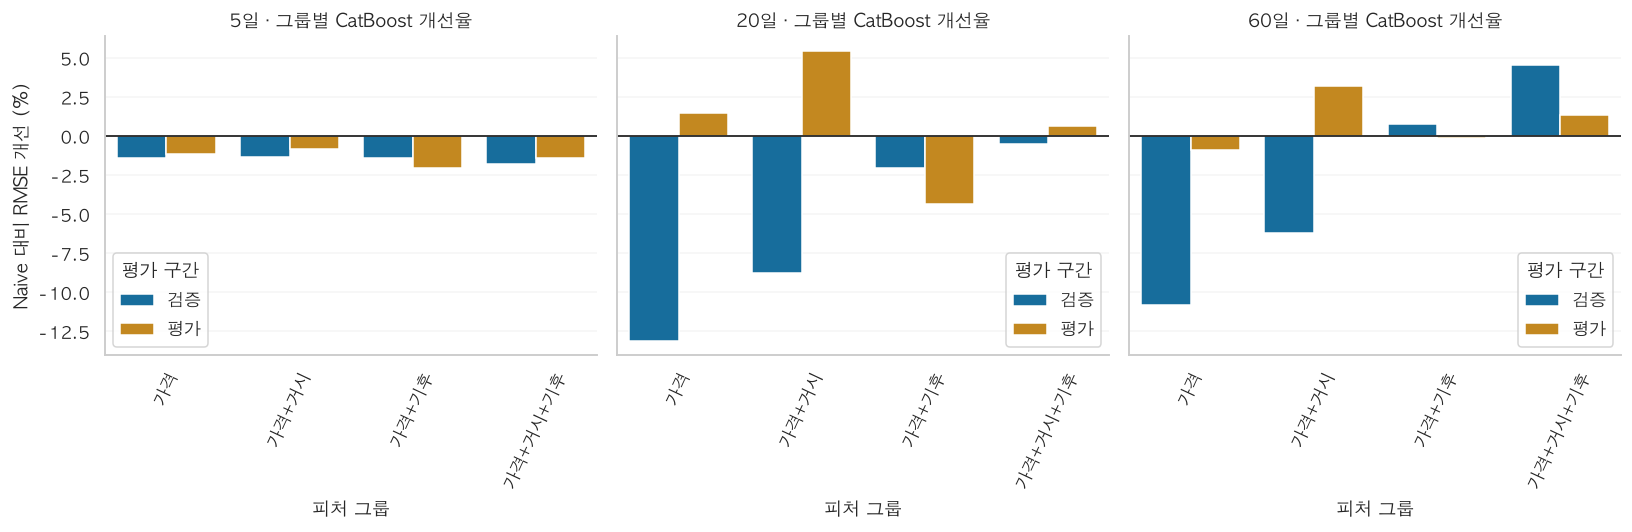

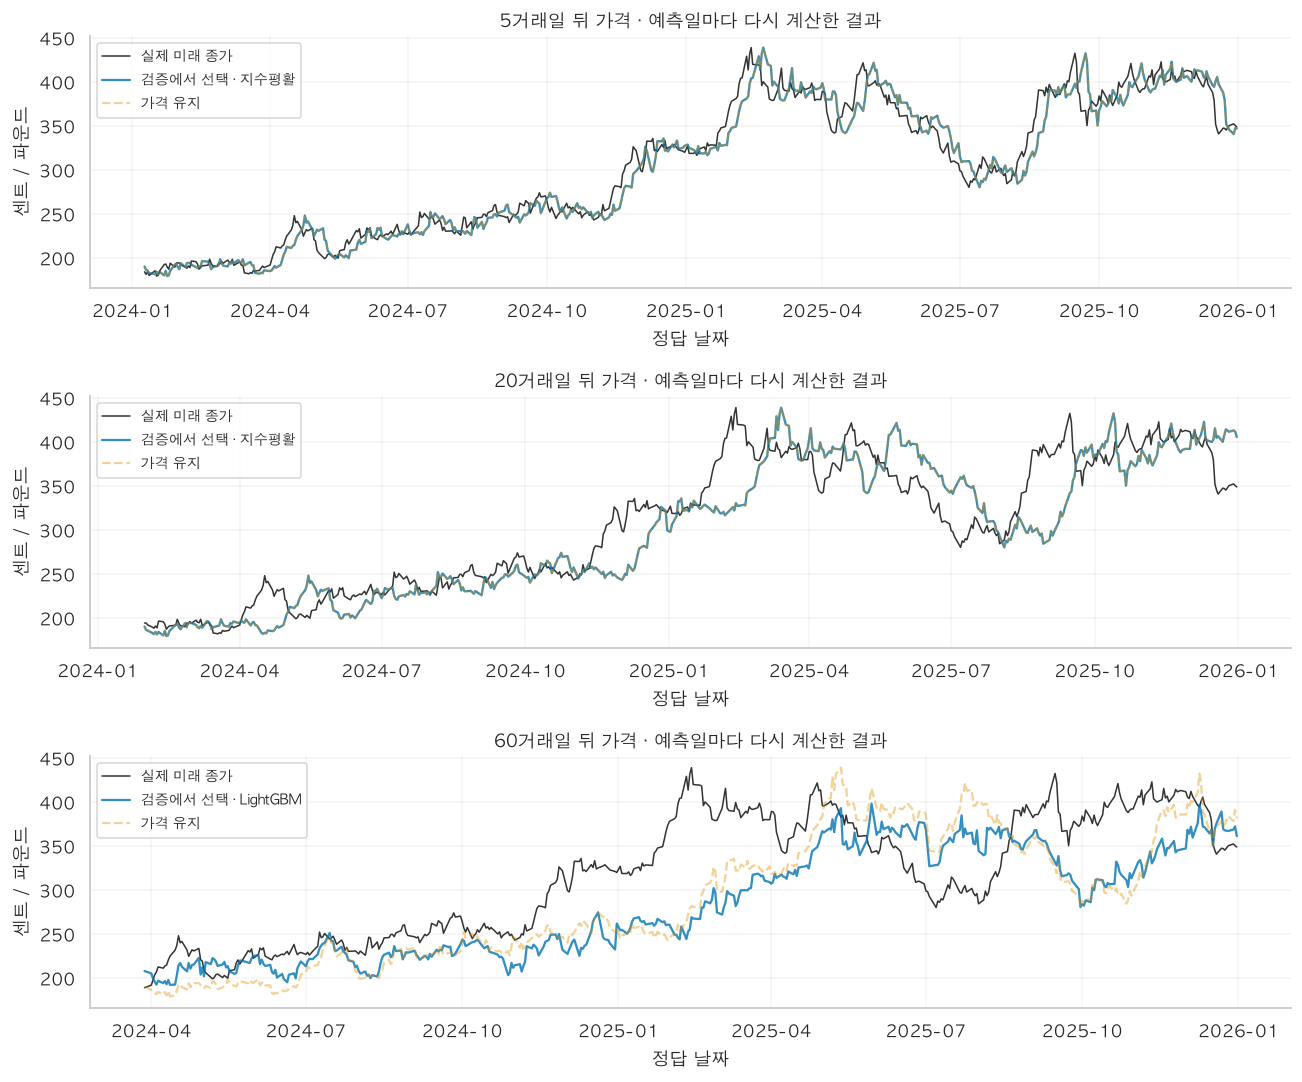

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, h in zip(axes, HORIZONS):
    part = pd.concat([ablation_validation, ablation_test]).query("지평 == @h").copy()
    part["구간"] = part["구간"].replace({"Validation": "검증", "Test": "평가"})
    sns.barplot(data=part, x="그룹", y="Naive 대비 개선 (%)", hue="구간", ax=ax)
    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"{h}일 · 그룹별 CatBoost 개선율")
    ax.set_xlabel("피처 그룹")
    ax.set_ylabel("Naive 대비 RMSE 개선 (%)")
    ax.tick_params(axis="x", rotation=65)
    ax.legend(title="평가 구간")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for ax, h in zip(axes, HORIZONS):
    indices = FINAL_SPLITS[h]["Test"]
    dates = Y.iloc[indices][f"target_date_{h}"]
    origin_price = prices.iloc[indices].to_numpy()
    actual_price = origin_price * np.exp(Y.iloc[indices][f"y_{h}"].to_numpy())
    prediction = origin_price * np.exp(test_predictions[h, chosen_model[h]])
    ax.plot(dates, actual_price, label="실제 미래 종가", color="#333333", lw=1)
    ax.plot(dates, prediction, label=f"검증에서 선택 · {chosen_model[h]}", alpha=.8)
    ax.plot(dates, origin_price, label="가격 유지", alpha=.4, ls="--")
    ax.set(title=f"{h}거래일 뒤 가격 · 예측일마다 다시 계산한 결과", xlabel="정답 날짜", ylabel="센트 / 파운드")
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

In [16]:
summary = []
for h in HORIZONS:
    val_group = ablation_validation.query("지평 == @h").set_index("그룹")
    test_group = ablation_test.query("지평 == @h").set_index("그룹")
    group = selected_group[h]
    chosen = test_scores.loc[(test_scores["지평"] == h) & (test_scores["모델"] == chosen_model[h])].iloc[0]
    summary.append({"지평": h, "검증 선택 그룹": group, "선택 모델": chosen_model[h],
                    "평가 RMSE": chosen["RMSE"], "Naive 대비 개선 (%)": chosen["Naive 대비 개선 (%)"],
                    "가격 그룹 대비 검증 개선 (%)": 100*(1-val_group.loc[group,"RMSE"]/val_group.loc["가격","RMSE"]),
                    "가격 그룹 대비 평가 개선 (%)": 100*(1-test_group.loc[group,"RMSE"]/test_group.loc["가격","RMSE"])})
summary = pd.DataFrame(summary)
show_table(summary)

sensitivity = []
for h in HORIZONS:
    indices = FINAL_SPLITS[h]["Test"]
    actual = Y.iloc[indices][f"y_{h}"].to_numpy()
    prediction = test_predictions[h, chosen_model[h]]
    for year in (2024, 2025):
        mask = SESSIONS[indices].year == year
        sensitivity.append({"지평": h, "확인 구간": str(year), "표본": int(mask.sum()), **metrics(actual[mask], prediction[mask])})
    for offset in (0, h//3, 2*h//3):
        # 원래 거래일 순번에서 h칸씩 간다. 세 시작점을 독립 표본으로 합치지 않는다.
        mask = (indices-indices[0]-offset) % h == 0
        selected = indices[mask]
        assert (np.diff(selected) >= h).all()
        sensitivity.append({"지평": h, "확인 구간": f"비중첩 시작 {offset}", "표본": len(selected), **metrics(actual[mask], prediction[mask])})
show_table(pd.DataFrame(sensitivity))
display(Markdown("개선율이 양수면 오차가 감소했다. 방향 정확도에서 0은 보합이므로 Naive를 50% 기준선으로 읽지 않는다. "
                 "일별 타깃이 중첩되고 60일 비중첩 표본은 작다. 이 표는 안정성 점검이며 통계적 우월성 검정이 아니다. "
                 "단일 seed·작은 설정 후보·이미 본 Test라는 범위 안에서 해석한다. 서리 피처가 상수로 빠졌다면 가뭄×서리 가설은 이번 격자에서 검증하지 못한 것이다."))

|   지평 | 검증 선택 그룹   | 선택 모델   |   평가 RMSE |   Naive 대비 개선 (%) |   가격 그룹 대비 검증 개선 (%) |   가격 그룹 대비 평가 개선 (%) |
|-------:|:-----------------|:------------|------------:|----------------------:|-------------------------------:|-------------------------------:|
|      5 | 가격+거시        | 지수평활    |     0.05444 |              -0.00008 |                        0.05458 |                        0.29446 |
|     20 | 가격+거시+기후   | 지수평활    |     0.11300 |               0.00006 |                       11.14791 |                       -0.83056 |
|     60 | 가격+거시+기후   | LightGBM    |     0.18258 |               1.71322 |                       13.85230 |                        2.25364 |

|   지평 | 확인 구간      |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:---------------|-------:|--------:|--------:|------------------:|----------------------:|
|      5 | 2024           |    252 | 0.04872 | 0.03802 |          54.76190 |               0.00022 |
|      5 | 2025           |    246 | 0.05974 | 0.04771 |          47.15447 |              -0.00029 |
|      5 | 비중첩 시작 0  |    100 | 0.05255 | 0.04224 |          48.00000 |              -0.00051 |
|      5 | 비중첩 시작 1  |    100 | 0.05466 | 0.04297 |          50.00000 |               0.00048 |
|      5 | 비중첩 시작 3  |     99 | 0.05824 | 0.04537 |          52.52525 |               0.00028 |
|     20 | 2024           |    252 | 0.09932 | 0.07295 |          53.57143 |               0.00018 |
|     20 | 2025           |    231 | 0.12626 | 0.09894 |          48.05195 |              -0.00002 |
|     20 | 비중첩 시작 0  |     25 | 0.12468 | 0.09311 |          52.00000 |               0.00041 |
|     20 | 비중첩 시작 6  |     24 | 0.09759 | 0.07948 |          58.33333 |               0.00018 |
|     20 | 비중첩 시작 13 |     24 | 0.13186 | 0.09997 |          45.83333 |               0.00035 |
|     60 | 2024           |    252 | 0.19954 | 0.16119 |          55.15873 |              -4.40116 |
|     60 | 2025           |    191 | 0.15742 | 0.13956 |          68.58639 |              11.77240 |
|     60 | 비중첩 시작 0  |      8 | 0.17768 | 0.15065 |          50.00000 |             -29.14732 |
|     60 | 비중첩 시작 20 |      8 | 0.14676 | 0.11998 |          50.00000 |              10.24948 |
|     60 | 비중첩 시작 40 |      7 | 0.24632 | 0.18686 |          71.42857 |              -1.09139 |

개선율이 양수면 오차가 감소했다. 방향 정확도에서 0은 보합이므로 Naive를 50% 기준선으로 읽지 않는다. 일별 타깃이 중첩되고 60일 비중첩 표본은 작다. 이 표는 안정성 점검이며 통계적 우월성 검정이 아니다. 단일 seed·작은 설정 후보·이미 본 Test라는 범위 안에서 해석한다. 서리 피처가 상수로 빠졌다면 가뭄×서리 가설은 이번 격자에서 검증하지 못한 것이다.

**실행 확인**

마지막으로 미래 자료를 바꿔도 Train 입력·선택이 달라지지 않는지, 거래일 누락을 유지한 타깃이 맞는지 확인한다.
이 검사는 시간 정렬 코드에 대한 것이며 원천 자료의 과거 수정 문제까지 해결하지는 않는다.

In [17]:
# 합성 가격으로 시차 방향과 결측 위치를 확인한다.
toy = pd.Series([10., 11., np.nan, 13., 14., 15., 16., 17., 18., 19.], index=pd.bdate_range("2020-01-01", periods=10))
toy_targets = make_targets(toy)
assert toy_targets.target_date_5.iloc[0] == toy.index[5]
np.testing.assert_allclose(toy_targets.y_5.iloc[0], np.log(15/10))
assert pd.isna(toy_targets.y_5.iloc[2])
assert toy.shift(2).iloc[3] == toy.iloc[1]

for cutoff in (TRAIN_END, VAL_END):
    changed = {k: v.copy(deep=True) for k,v in sources.items()}
    for key, frame in changed.items():
        mask = frame.date > cutoff
        numeric = frame.select_dtypes(include="number").columns
        frame[numeric] = frame[numeric].astype(float)
        frame.loc[mask, numeric] = frame.loc[mask, numeric] * 1.1 + .01
        if "release_date" in frame:
            mask = pd.to_datetime(frame.release_date) + pd.Timedelta(days=1) > cutoff
            frame.loc[mask, "value"] = frame.loc[mask, "value"] + 99
    before, _, _, _ = build_features(sources, cutoff)
    after, _, _, _ = build_features(changed, cutoff)
    pd.testing.assert_frame_equal(before.loc[:cutoff], after.loc[:cutoff])
    changed_prices = changed["coffee"].set_index("date").close.reindex(SESSIONS)
    changed_y = make_targets(changed_prices)
    for h in HORIZONS:
        mask = Y[f"target_date_{h}"].le(cutoff)
        pd.testing.assert_series_equal(Y.loc[mask, f"y_{h}"], changed_y.loc[mask, f"y_{h}"])
        if cutoff == TRAIN_END:
            old, _ = reduced_weather(before, Y[f"y_{h}"].where(mask), cutoff)
            new, _ = reduced_weather(after, changed_y[f"y_{h}"].where(mask), cutoff)
            assert old == new

for h in HORIZONS:
    for name, indices in SPLITS[h].items():
        assert X.iloc[indices][FEATURES].notna().all().all()
    te = FINAL_SPLITS[h]["Test"]
    for family in test_scores["모델"].unique():
        row = test_scores.loc[(test_scores["지평"]==h) & (test_scores["모델"]==family)].iloc[0]
        measured = metrics(Y.iloc[te][f"y_{h}"], test_predictions[h, family])
        np.testing.assert_allclose([row["RMSE"], row["MAE"]], [measured["RMSE"], measured["MAE"]])
# 고정 모수 업데이트도 새 관측에 반응하는지 작은 예제로 확인한다.
example = pd.Series(np.log(10 + np.arange(80)*.03 + np.sin(np.arange(80))*.1))
updating = PriceForecaster("ses").fit(example.iloc[:60], fh=[5])
before_update = float(updating.predict(fh=[5]).iloc[0])
updating.update(example.iloc[60:65] + .1, update_params=False)
assert int(updating.cutoff[0]) == 64
assert not np.isclose(float(updating.predict(fh=[5]).iloc[0]), before_update)
print("확인 완료: 미래 변경 불변성 · 정답 경계 · 공통 행 · 거래일 시차 · 결측 유지 · 표 지표 일치")

확인 완료: 미래 변경 불변성 · 정답 경계 · 공통 행 · 거래일 시차 · 결측 유지 · 표 지표 일치
